In [6]:
import json
import requests
import pandas as pd

df = pd.read_csv('/home/jovyan/work/drug_target_validation/data/manually_curated_merged_drug_divided_original_condition_filtered.csv')
#df_segment = df.iloc[800:900]
df_segment = df.head(100)


results = []
for index, row in df_segment.iterrows():
    TT = row['Study Title']
    BS = row['Brief Summary']
    DG = row['Drug']
    NCT = row['NCT Number']
    prompt = f"""
From the study Title (TT), Brief Summary (BS), and the investigational drug name (DG),
1) Identify each human-cell molecular target of the investigational drug (DG).
2) For each target, list all synonyms that refer to EXACTLY the same target. IT IS VERY IMPORTANT THAT TARGETS AND THE CORRESPONDING SYNONYMS MEAN EXACTLY THE SAME THING.
6) If no target can be identified, OR, if you do not know the target of the investigational drug, output exactly: NA

Format (one line only):
"target1, syn1, syn2, ...; target2, syn1, syn2, ..."

TT: {TT}
BS: {BS}
DG: {DG}

""".strip()

    response = requests.post(
        url="https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer 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",
            "Content-Type": "application/json",
        },
        data=json.dumps({
            "model": "google/gemini-3-flash-preview",
            "messages": [{"role": "user", "content": prompt}]
        }),
        timeout=30
    )

    if response.status_code == 200:
        result = response.json()
        target = result["choices"][0]["message"]["content"].strip()
    else:
        target = f"Error: {response.status_code}"

    results.append({
        "NCT Number": NCT,
        "Drug": DG,
        "Target": target
    })

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("/home/jovyan/work/drug_target_validation/data/targetname_rlt_TT_BS_IN/0ie_gemini-3-flash-preview_TT_BS_DG_condition_filtered.csv", index=False)

KeyboardInterrupt: 

In [3]:
import pandas as pd
import glob

# Specify your input folder path and output file path
input_path = '/home/jovyan/work/literature_rag_new_trials/data/targetname_rlt_TT_BS_IN/*gemini*.csv'  # Change this to your folder
output_path = '/home/jovyan/work/literature_rag_new_trials/data/gemini_targets_condition_filtered.csv'  # Change this to your desired output

# Get file paths and sort them
file_paths = sorted(glob.glob(input_path))

# Stack all CSVs in sorted order
df = pd.concat([pd.read_csv(f) for f in file_paths], ignore_index=True)
df.to_csv(output_path, index=False)

#use gemini_targets_condition_filtered.csv and manually_curated_merged_drug_divided_original_condition_filtered.csv to get target_final_manually_curated

Creating logarithmic scale heatmap...

Processing 656 valid records...
Unique isotopes: 26
Unique targets: 93

Including 26 isotopes and 98 targets in heatmap

Target order (left to right, most to least frequent):
  First 5: ['folh1', 'sstr2', 'fap', 'net', 'bombesin receptor subtype 2']
  Last 5: ['ldl receptor', 'sodium-potassium adenosine triphosphatase', 'androgen receptor', 'bcl2', 'gpc3']

Isotope order (bottom to top, most to least frequent):
  Bottom 5 (most frequent): ['18F-F', '68Ga/18F', '[177Lu]', '223Ra', '67Cu']
  Top 5 (least frequent): ['99mTc', '225Ac', '18F', '177Lu', '68Ga']

Heatmap dimensions: 26 isotopes × 98 targets
Total cells: 2548
Non-zero cells: 202
Log scale range: 0.1000 to 79.1000

Heatmap saved to: /home/jovyan/work/literature_rag_new_trials/data/figures/isotope_target_heatmap_log_original.pdf


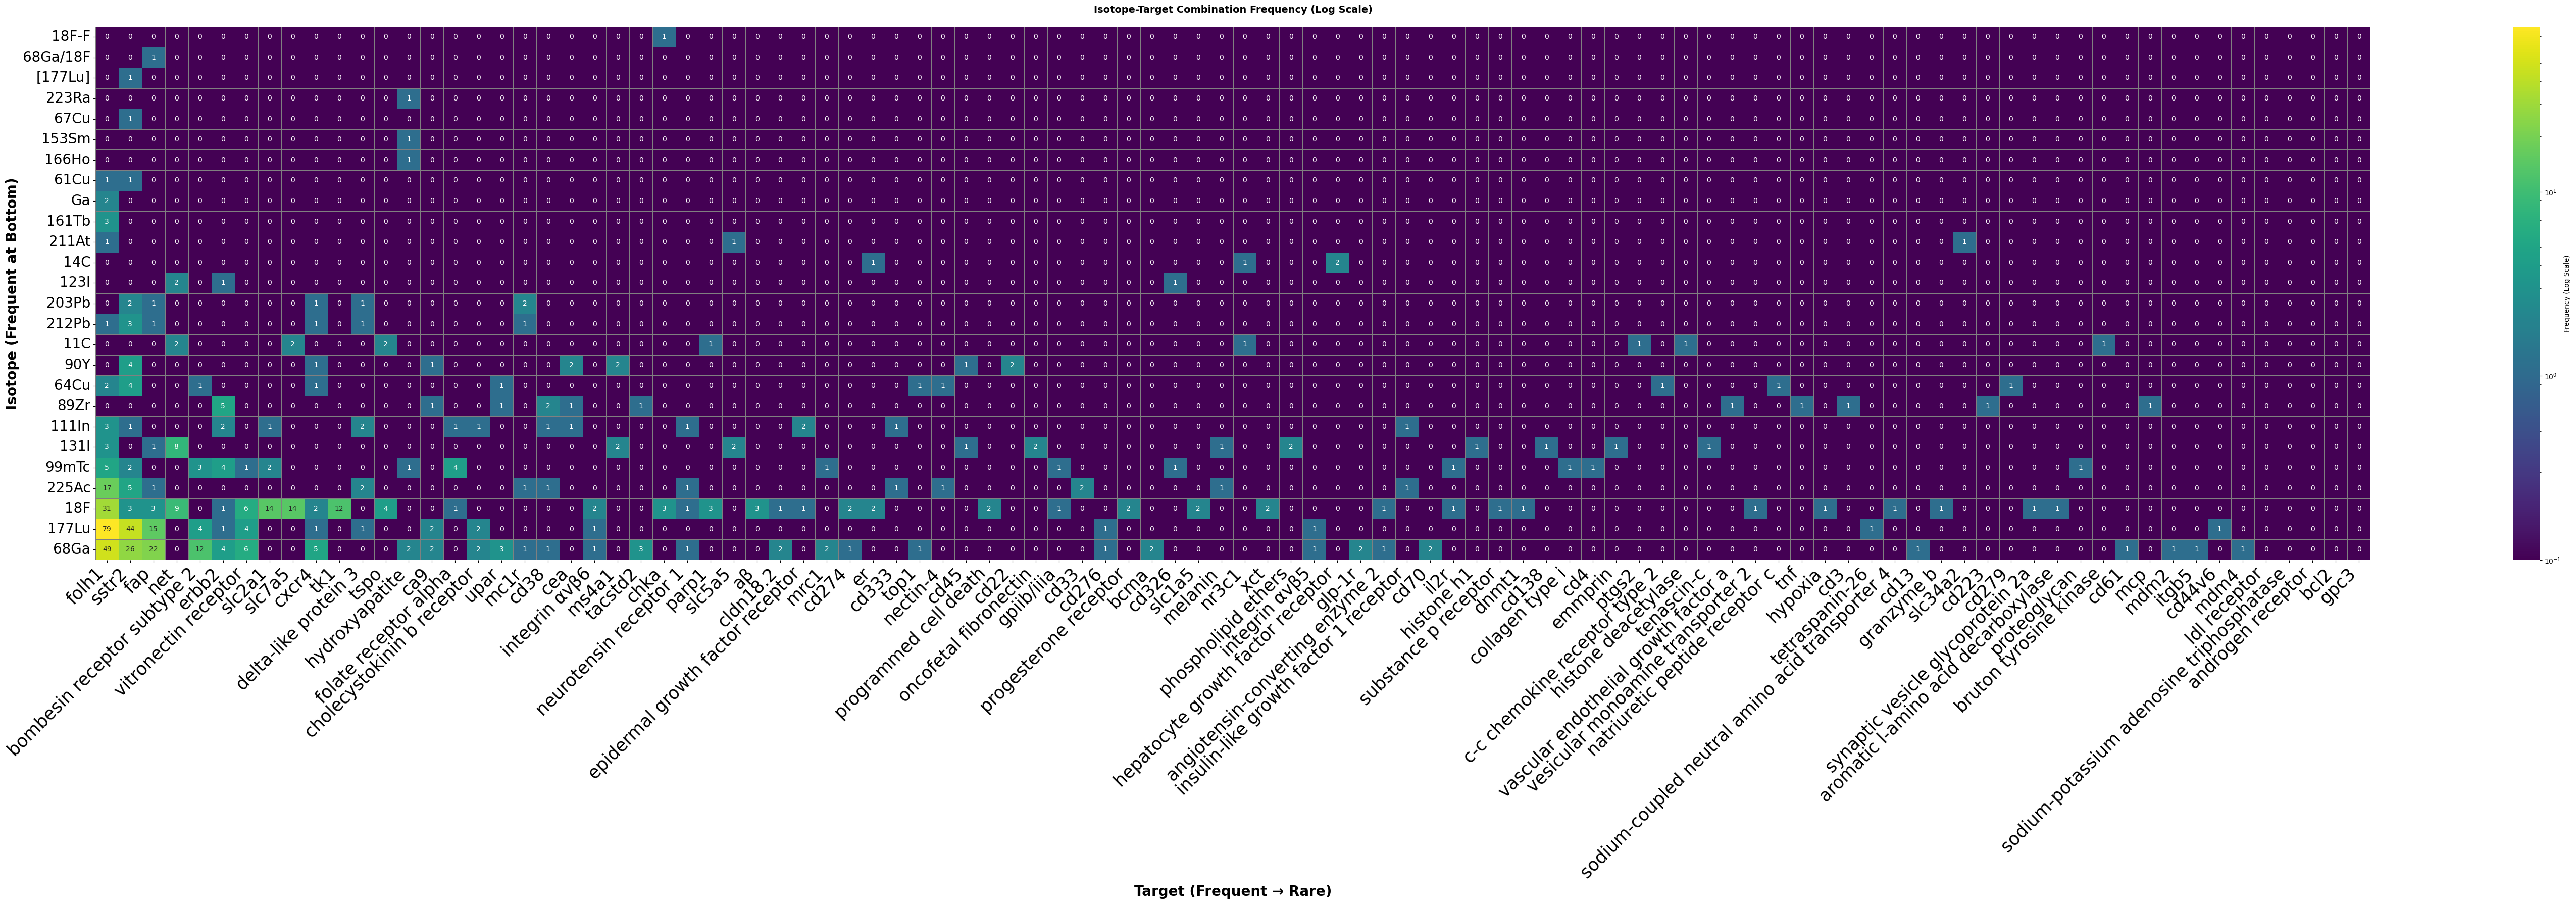


Frequency table saved!

SUMMARY STATISTICS
Total unique isotopes: 26
Total unique targets: 98
Total combinations: 2548
Non-zero combinations: 202
Zero combinations: 2346

Value range:
  Minimum (non-zero): 1
  Maximum: 79
  Mean (non-zero): 1.96
  Median (non-zero): 1.00

Top 5 most common isotopes (at bottom of heatmap):
  68Ga: 160
  177Lu: 158
  18F: 137
  225Ac: 34
  99mTc: 29

Top 5 most common targets (at left of heatmap):
  folh1: 197
  sstr2: 97
  fap: 45
  net: 21
  bombesin receptor subtype 2: 20

Top 10 most frequent combinations:
  177Lu + folh1: 79
  68Ga + folh1: 49
  177Lu + sstr2: 44
  18F + folh1: 31
  68Ga + sstr2: 26
  68Ga + fap: 22
  225Ac + folh1: 17
  177Lu + fap: 15
  18F + slc2a1: 14
  18F + slc7a5: 14


VERIFYING ORDER:

Target frequencies (should decrease left to right):
  Position 1: folh1 = 208 occurrences
  Position 2: sstr2 = 107 occurrences
  Position 3: fap = 47 occurrences
  Position 4: net = 21 occurrences
  Position 5: bombesin receptor subtype 2 = 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LogNorm


def create_isotope_target_heatmap_log_scale(df, isotope_col='Isotope', target_col='Target', 
                                            figsize=(18, 12), cmap='viridis', 
                                            save_path=None, title='Isotope-Target Combination Frequency (Log Scale)',
                                            show_all_targets=True, show_all_isotopes=True,
                                            cell_aspect=1.5):
    """
    Create a heatmap with LOGARITHMIC color scale - makes rare values much more visible!
    Targets: Most frequent (LEFT) to rare (RIGHT)
    Isotopes: Most frequent (BOTTOM) to rare (TOP)
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe containing isotope and target columns
    isotope_col : str
        Name of the isotope column
    target_col : str
        Name of the target column
    figsize : tuple
        Base figure size (width, height) - will be adjusted based on data
    cmap : str
        Colormap name for the heatmap
    save_path : str, optional
        Path to save the figure
    title : str
        Title for the heatmap
    show_all_targets : bool
        If True, include all targets even if they have no combinations with any isotope
    show_all_isotopes : bool
        If True, include all isotopes even if they have no combinations with any target
    cell_aspect : float
        Aspect ratio for cells (higher = wider cells). Default 1.5 makes cells wider than tall
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    pivot_df : DataFrame with the frequency counts (original scale, not log)
    """
    
    # Create a copy of relevant columns and drop NAs
    data = df[[isotope_col, target_col]].copy()
    data = data.dropna()
    
    print(f"\nProcessing {len(data)} valid records...")
    print(f"Unique isotopes: {data[isotope_col].nunique()}")
    print(f"Unique targets: {data[target_col].nunique()}")
    
    # Count combinations
    combination_counts = data.groupby([isotope_col, target_col]).size().reset_index(name='count')
    
    # Get ALL unique values
    if show_all_isotopes:
        all_isotopes = df[isotope_col].dropna().unique()
    else:
        all_isotopes = data[isotope_col].unique()
    
    if show_all_targets:
        all_targets = df[target_col].dropna().unique()
    else:
        all_targets = data[target_col].unique()
    
    print(f"\nIncluding {len(all_isotopes)} isotopes and {len(all_targets)} targets in heatmap")
    
    # Get frequency ranking for isotopes (most common to rare)
    isotope_freq = data[isotope_col].value_counts()
    isotope_order = isotope_freq.index.tolist()
    # Add any isotopes not in the data (will have 0 count) - these go at the end (top)
    isotope_order.extend([iso for iso in all_isotopes if iso not in isotope_order])
    
    # REVERSE the isotope order so most frequent is at BOTTOM, rare at TOP
    isotope_order = isotope_order[::-1]
    
    # Get frequency ranking for targets (most common to rare)
    target_freq = data[target_col].value_counts()
    target_order = target_freq.index.tolist()
    # Add any targets not in the data (will have 0 count) - these go at the end (right)
    target_order.extend([tgt for tgt in all_targets if tgt not in target_order])
    
    # DON'T reverse target order - keep most frequent on LEFT, rare on RIGHT
    # target_order is already in the correct order (most frequent first)
    
    print(f"\nTarget order (left to right, most to least frequent):")
    print(f"  First 5: {target_order[:5]}")
    print(f"  Last 5: {target_order[-5:]}")
    
    print(f"\nIsotope order (bottom to top, most to least frequent):")
    print(f"  Bottom 5 (most frequent): {isotope_order[:5]}")
    print(f"  Top 5 (least frequent): {isotope_order[-5:]}")
    
    # Create pivot table
    pivot_df = combination_counts.pivot(index=isotope_col, columns=target_col, values='count')
    
    # Reindex to include all isotopes and targets
    pivot_df = pivot_df.reindex(index=isotope_order, columns=target_order)
    pivot_df = pivot_df.fillna(0)
    
    # Add small value to avoid log(0)
    pivot_df_log = pivot_df + 0.1
    
    print(f"\nHeatmap dimensions: {pivot_df.shape[0]} isotopes × {pivot_df.shape[1]} targets")
    print(f"Total cells: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero cells: {(pivot_df > 0).sum().sum()}")
    
    # Calculate figure size
    n_rows = pivot_df.shape[0]
    n_cols = pivot_df.shape[1]
    fig_width = max(figsize[0], n_cols * 0.4 * cell_aspect)
    fig_height = max(figsize[1], n_rows * 0.4)
    
    # Create the heatmap with log scale
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate vmin and vmax as scalar values (not Series)
    vmin_value = pivot_df_log[pivot_df_log > 0].min().min()
    vmax_value = pivot_df_log.max().max()
    
    print(f"Log scale range: {vmin_value:.4f} to {vmax_value:.4f}")
    
    # Use logarithmic normalization
    sns.heatmap(pivot_df_log, 
                annot=pivot_df.astype(int),  # Show original values, not log values
                fmt='g',
                cmap=cmap,
                norm=LogNorm(vmin=vmin_value, vmax=vmax_value),
                cbar_kws={'label': 'Frequency (Log Scale)'},
                linewidths=0.5,
                linecolor='gray',
                ax=ax,
                square=False)
    
    # Customize plot
    ax.set_xlabel('Target (Frequent → Rare)', fontsize=20, fontweight='bold')
    ax.set_ylabel('Isotope (Frequent at Bottom)', fontsize=20, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.xticks(rotation=45, ha='right', fontsize=25)
    plt.yticks(rotation=0, fontsize=20)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nHeatmap saved to: {save_path}")
    
    return fig, ax, pivot_df


# Main execution
if __name__ == "__main__":
    # Load your data
    df = pd.read_csv('/home/jovyan/work/drug_target_validation/data/target_final_manually_curated.csv')
    
    print("=" * 70)
    print("Creating logarithmic scale heatmap...")
    print("=" * 70)
    
    # Create the log-scale heatmap
    fig, ax, pivot_df = create_isotope_target_heatmap_log_scale(
        df,
        isotope_col='Isotope',
        target_col='Target',
        figsize=(20, 18),
        cmap='viridis',  # Good options: 'viridis', 'plasma', 'inferno', 'magma'
        save_path='/home/jovyan/work/drug_target_validation/data/figures/isotope_target_heatmap_log_original.pdf',
        title='Isotope-Target Combination Frequency (Log Scale)',
        show_all_targets=True,
        show_all_isotopes=True,
        cell_aspect=1.5  # Makes cells wider
    )
    
    plt.show()
    
    
    # Print summary statistics
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    print(f"Total unique isotopes: {len(pivot_df.index)}")
    print(f"Total unique targets: {len(pivot_df.columns)}")
    print(f"Total combinations: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero combinations: {(pivot_df > 0).sum().sum()}")
    print(f"Zero combinations: {(pivot_df == 0).sum().sum()}")
    
    print(f"\nValue range:")
    print(f"  Minimum (non-zero): {pivot_df[pivot_df > 0].min().min():.0f}")
    print(f"  Maximum: {pivot_df.max().max():.0f}")
    print(f"  Mean (non-zero): {pivot_df[pivot_df > 0].mean().mean():.2f}")
    print(f"  Median (non-zero): {pivot_df[pivot_df > 0].median().median():.2f}")
    
    print("\nTop 5 most common isotopes (at bottom of heatmap):")
    isotope_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
    for isotope, count in isotope_totals.head(5).items():
        print(f"  {isotope}: {count:.0f}")
    
    print("\nTop 5 most common targets (at left of heatmap):")
    target_totals = pivot_df.sum(axis=0).sort_values(ascending=False)
    for target, count in target_totals.head(5).items():
        print(f"  {target}: {count:.0f}")
    
    print("\nTop 10 most frequent combinations:")
    combo_list = []
    for isotope in pivot_df.index:
        for target in pivot_df.columns:
            value = pivot_df.loc[isotope, target]
            if value > 0:
                combo_list.append((isotope, target, value))
    
    combo_list.sort(key=lambda x: x[2], reverse=True)
    for isotope, target, count in combo_list[:10]:
        print(f"  {isotope} + {target}: {count:.0f}")
    
    print("\n" + "=" * 70)
    
    # Verify ordering
    print("\nVERIFYING ORDER:")
    print("=" * 70)
    print("\nTarget frequencies (should decrease left to right):")
    for i, target in enumerate(pivot_df.columns[:10]):
        freq = (df[df['Target'] == target].shape[0])
        print(f"  Position {i+1}: {target} = {freq} occurrences")
    
    print("\nIsotope frequencies (should decrease bottom to top):")
    for i, isotope in enumerate(pivot_df.index[:10]):
        freq = (df[df['Isotope'] == isotope].shape[0])
        print(f"  Position {i+1} from bottom: {isotope} = {freq} occurrences")

    #    (PSMA, SSTR2, FAP, NET, GRPR, HER2, CD51/CD61, GLUT1, LAT1, CXCR4, TK1, DLL3, TSPO, hydroxyapatite, CA9, FOLR1, CCKBR, PLAUR, MC1R, CD38, CEA, integrin αvβ6, CD20, TROP2, CHKA, NTSR1, PARP1, SLC5A5, amyloid beta, CLDN18.2, EGFR, CD206, CD274, ESR1, CD333, TOP1, NECTIN4, CD45, apoptosis, CD22, oncofetal fibronectin/FN1, ITGA2B, CD33, CD276, PGR, CD269, CD326, SLC1A5, melanin, NR3C1, SLC7A11, phospholipid ethers, integrin αvβ5, MET, GLP1R, ACE2, IGF1R, CD70, CD25, HIST1, NK1R, DNMT1, CD138, COL1A1, CD4, CD147, PTGS2/COX2, CCR2/CD192, histone deacetylase, TNC, VEGFA, VMAT2, NPR3, TNF, hypoxia, CD3, CD37, SLC38A4, CD13, granzyme b, 
#SLC34A2, CD223, CD279, CV2A, aromatic I-amino acid decarboxylase, PRG4, BTK, CD61, CD46, MDM2, ITGB5, CD44v6, MDM4, A, B, C, D, E)     

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LogNorm


def create_isotope_target_heatmap_log_scale(df, isotope_col='Isotope', target_col='Target', 
                                            figsize=(18, 12), cmap='viridis', 
                                            save_path=None, title='Isotope-Target Combination Frequency (Log Scale)',
                                            show_all_targets=True, show_all_isotopes=True,
                                            cell_aspect=1.5, custom_target_labels=None,
                                            remove_n_least_frequent_targets=0,
                                            remove_n_least_frequent_isotopes=0,
                                            annot_fontsize=14):
    """
    Create a heatmap with LOGARITHMIC color scale - makes rare values much more visible!
    Targets: Most frequent (LEFT) to rare (RIGHT)
    Isotopes: Most frequent (BOTTOM) to rare (TOP)
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe containing isotope and target columns
    isotope_col : str
        Name of the isotope column
    target_col : str
        Name of the target column
    figsize : tuple
        Base figure size (width, height) - will be adjusted based on data
    cmap : str
        Colormap name for the heatmap
    save_path : str, optional
        Path to save the figure
    title : str
        Title for the heatmap
    show_all_targets : bool
        If True, include all targets even if they have no combinations with any isotope
    show_all_isotopes : bool
        If True, include all isotopes even if they have no combinations with any target
    cell_aspect : float
        Aspect ratio for cells (higher = wider cells). Default 1.5 makes cells wider than tall
    custom_target_labels : list, optional
        List of custom labels for the x-axis (targets) in the exact order to display
    remove_n_least_frequent_targets : int
        Number of least frequent targets to remove from the heatmap
    remove_n_least_frequent_isotopes : int
        Number of least frequent isotopes to remove from the heatmap
    annot_fontsize : int
        Font size for the numbers displayed in each cell
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    pivot_df : DataFrame with the frequency counts (original scale, not log)
    """
    
    # Create a copy of relevant columns and drop NAs
    data = df[[isotope_col, target_col]].copy()
    data = data.dropna()
    
    print(f"\nProcessing {len(data)} valid records...")
    print(f"Unique isotopes: {data[isotope_col].nunique()}")
    print(f"Unique targets: {data[target_col].nunique()}")
    
    # Count combinations
    combination_counts = data.groupby([isotope_col, target_col]).size().reset_index(name='count')
    
    # Get ALL unique values
    if show_all_isotopes:
        all_isotopes = df[isotope_col].dropna().unique()
    else:
        all_isotopes = data[isotope_col].unique()
    
    if show_all_targets:
        all_targets = df[target_col].dropna().unique()
    else:
        all_targets = data[target_col].unique()
    
    print(f"\nIncluding {len(all_isotopes)} isotopes and {len(all_targets)} targets in heatmap")
    
    # Get frequency ranking for isotopes (most common to rare)
    isotope_freq = data[isotope_col].value_counts()
    isotope_order = isotope_freq.index.tolist()
    # Add any isotopes not in the data (will have 0 count) - these go at the end (top)
    isotope_order.extend([iso for iso in all_isotopes if iso not in isotope_order])
    
    # Remove N least frequent isotopes
    if remove_n_least_frequent_isotopes > 0:
        removed_isotopes = isotope_order[-remove_n_least_frequent_isotopes:]
        isotope_order = isotope_order[:-remove_n_least_frequent_isotopes]
        print(f"\nRemoved {remove_n_least_frequent_isotopes} least frequent isotopes:")
        for iso in removed_isotopes:
            print(f"  - {iso}")
    
    # REVERSE the isotope order so most frequent is at BOTTOM, rare at TOP
    isotope_order = isotope_order[::-1]
    
    # Get frequency ranking for targets (most common to rare)
    target_freq = data[target_col].value_counts()
    target_order = target_freq.index.tolist()
    # Add any targets not in the data (will have 0 count) - these go at the end (right)
    target_order.extend([tgt for tgt in all_targets if tgt not in target_order])
    
    # Remove N least frequent targets
    if remove_n_least_frequent_targets > 0:
        removed_targets = target_order[-remove_n_least_frequent_targets:]
        target_order = target_order[:-remove_n_least_frequent_targets]
        print(f"\nRemoved {remove_n_least_frequent_targets} least frequent targets:")
        for tgt in removed_targets:
            print(f"  - {tgt}")
    
    # DON'T reverse target order - keep most frequent on LEFT, rare on RIGHT
    # target_order is already in the correct order (most frequent first)
    
    print(f"\nTarget order (left to right, most to least frequent):")
    print(f"  First 5: {target_order[:5]}")
    print(f"  Last 5: {target_order[-5:]}")
    
    print(f"\nIsotope order (bottom to top, most to least frequent):")
    print(f"  Bottom 5 (most frequent): {isotope_order[:5]}")
    print(f"  Top 5 (least frequent): {isotope_order[-5:]}")
    
    # Create pivot table
    pivot_df = combination_counts.pivot(index=isotope_col, columns=target_col, values='count')
    
    # Reindex to include only the filtered isotopes and targets
    pivot_df = pivot_df.reindex(index=isotope_order, columns=target_order)
    pivot_df = pivot_df.fillna(0)
    
    # Add small value to avoid log(0)
    pivot_df_log = pivot_df + 0.1
    
    print(f"\nHeatmap dimensions: {pivot_df.shape[0]} isotopes × {pivot_df.shape[1]} targets")
    print(f"Total cells: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero cells: {(pivot_df > 0).sum().sum()}")
    
    # Calculate figure size
    n_rows = pivot_df.shape[0]
    n_cols = pivot_df.shape[1]
    fig_width = max(figsize[0], n_cols * 0.4 * cell_aspect)
    fig_height = max(figsize[1], n_rows * 0.4)
    
    # Create the heatmap with log scale
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate vmin and vmax as scalar values (not Series)
    vmin_value = pivot_df_log[pivot_df_log > 0].min().min()
    vmax_value = pivot_df_log.max().max()
    
    print(f"Log scale range: {vmin_value:.4f} to {vmax_value:.4f}")
    
    # Use logarithmic normalization
    sns.heatmap(pivot_df_log, 
                annot=pivot_df.astype(int),  # Show original values, not log values
                fmt='g',
                annot_kws={'size': annot_fontsize, 'weight': 'bold'},  # BIGGER CELL NUMBERS
                cmap=cmap,
                norm=LogNorm(vmin=vmin_value, vmax=vmax_value),
                cbar_kws={'label': 'Frequency (Log Scale)'},
                linewidths=0.5,
                linecolor='gray',
                ax=ax,
                square=False)
    
    # Customize plot - BIGGER FONT SIZES
    ax.set_xlabel('Target (Frequent → Rare)', fontsize=30, fontweight='bold')
    ax.set_ylabel('Isotope (Frequent at Bottom)', fontsize=30, fontweight='bold')
    ax.set_title(title, fontsize=24, fontweight='bold', pad=20)
    
    # Apply custom target labels if provided
    if custom_target_labels is not None:
        # Adjust custom labels to account for removed targets
        n_labels = len(pivot_df.columns)
        adjusted_labels = custom_target_labels[:n_labels]
        ax.set_xticklabels(adjusted_labels, rotation=45, ha='right', fontsize=25)
        print(f"\nApplied {n_labels} custom target labels (removed last {remove_n_least_frequent_targets} from label list)")
    else:
        plt.xticks(rotation=45, ha='right', fontsize=25)
    
    plt.yticks(rotation=0, fontsize=20)
    
    # Make colorbar label bigger
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel('Frequency (Log Scale)', fontsize=26, fontweight='bold')
    cbar.ax.tick_params(labelsize=20)  # Make colorbar tick labels bigger too
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nHeatmap saved to: {save_path}")
    
    return fig, ax, pivot_df


# Main execution
if __name__ == "__main__":
    # Load your data
    df = pd.read_csv('/home/jovyan/work/drug_target_validation/data/target_final_manually_curated.csv')
    
    # Your curated target labels in the exact order you want them displayed
    custom_target_labels = [
        "PSMA", "SSTR2", "FAP", "NET", "GRPR", "HER2", "CD51/CD61", "GLUT1", "LAT1", 
        "CXCR4", "TK1", "DLL3", "TSPO", "hydroxyapatite", "CA9", "FOLR1", "CCKBR", 
        "PLAUR", "MC1R", "CD38", "CEA", "integrin αvβ6", "CD20", "TROP2", "CHKA", 
        "NTSR1", "PARP1", "SLC5A5", "amyloid beta", "CLDN18.2", "EGFR", "CD206", 
        "CD274", "ESR1", "CD333", "TOP1", "NECTIN4", "CD45", "apoptosis", "CD22", 
        "oncofetal fibronectin/FN1", "ITGA2B", "CD33", "CD276", "PGR", "CD269", 
        "CD326", "SLC1A5", "melanin", "NR3C1", "SLC7A11", "phospholipid ethers", 
        "integrin αvβ5", "MET", "GLP1R", "ACE2", "IGF1R", "CD70", "CD25", "HIST1", 
        "NK1R", "DNMT1", "CD138", "COL1A1", "CD4", "CD147", "PTGS2/COX2", 
        "CCR2/CD192", "histone deacetylase", "TNC", "VEGFA", "VMAT2", "NPR3", "TNF", 
        "hypoxia", "CD3", "CD37", "SLC38A4", "CD13", "granzyme b", "SLC34A2", "CD223", 
        "CD279", "CV2A", "aromatic I-amino acid decarboxylase", "PRG4", "BTK", "CD61", 
        "CD46", "MDM2", "ITGB5", "CD44v6", "MDM4", "A", "B", "C", "D", "E"
    ]
    
    print("=" * 70)
    print("Creating logarithmic scale heatmap...")
    print("=" * 70)
    
    # Create the log-scale heatmap
    fig, ax, pivot_df = create_isotope_target_heatmap_log_scale(
        df,
        isotope_col='Isotope',
        target_col='Target',
        figsize=(20, 18),
        cmap='viridis',
        save_path='/home/jovyan/work/drug_target_validation/data/figures/isotope_target_heatmap_log.png',
        title='Isotope-Target Combination Frequency (Log Scale)',
        show_all_targets=True,
        show_all_isotopes=True,
        cell_aspect=1.5,
        custom_target_labels=custom_target_labels,
        remove_n_least_frequent_targets=5,  # Remove 5 least frequent targets
        remove_n_least_frequent_isotopes=3,  # Remove 3 least frequent isotopes
        annot_fontsize=18  # BIGGER CELL NUMBERS - adjust this value as needed
    )
    
    plt.show()
    
    # Optionally save the frequency table
    pivot_df.to_csv('/home/jovyan/work/drug_target_validation/data/final_outputs/isotope_target_frequency_table.csv')
    print("\nFrequency table saved!")
    
    # Print summary statistics
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    print(f"Total unique isotopes: {len(pivot_df.index)}")
    print(f"Total unique targets: {len(pivot_df.columns)}")
    print(f"Total combinations: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero combinations: {(pivot_df > 0).sum().sum()}")
    print(f"Zero combinations: {(pivot_df == 0).sum().sum()}")
    
    print(f"\nValue range:")
    print(f"  Minimum (non-zero): {pivot_df[pivot_df > 0].min().min():.0f}")
    print(f"  Maximum: {pivot_df.max().max():.0f}")
    print(f"  Mean (non-zero): {pivot_df[pivot_df > 0].mean().mean():.2f}")
    print(f"  Median (non-zero): {pivot_df[pivot_df > 0].median().median():.2f}")
    
    print("\nTop 5 most common isotopes (at bottom of heatmap):")
    isotope_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
    for isotope, count in isotope_totals.head(5).items():
        print(f"  {isotope}: {count:.0f}")
    
    print("\nTop 5 most common targets (at left of heatmap):")
    target_totals = pivot_df.sum(axis=0).sort_values(ascending=False)
    for target, count in target_totals.head(5).items():
        print(f"  {target}: {count:.0f}")
    
    print("\nTop 10 most frequent combinations:")
    combo_list = []
    for isotope in pivot_df.index:
        for target in pivot_df.columns:
            value = pivot_df.loc[isotope, target]
            if value > 0:
                combo_list.append((isotope, target, value))
    
    combo_list.sort(key=lambda x: x[2], reverse=True)
    for isotope, target, count in combo_list[:10]:
        print(f"  {isotope} + {target}: {count:.0f}")
    
    print("\n" + "=" * 70)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LogNorm


def create_phase_target_heatmap_log_scale(df, phase_col='Phases', target_col='Target', 
                                          figsize=(18, 12), cmap='viridis', 
                                          save_path=None, title='Phase-Target Combination Frequency (Log Scale)',
                                          show_all_targets=True, show_all_phases=True,
                                          cell_aspect=1.5, custom_target_labels=None,
                                          remove_n_least_frequent_targets=0,
                                          annot_fontsize=14):
    """
    Create a heatmap with LOGARITHMIC color scale - makes rare values much more visible!
    Targets: Most frequent (LEFT) to rare (RIGHT)
    Phases: Ordered from EARLY_PHASE1 (BOTTOM) to NA (TOP)
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe containing phase and target columns
    phase_col : str
        Name of the phase column
    target_col : str
        Name of the target column
    figsize : tuple
        Base figure size (width, height) - will be adjusted based on data
    cmap : str
        Colormap name for the heatmap
    save_path : str, optional
        Path to save the figure
    title : str
        Title for the heatmap
    show_all_targets : bool
        If True, include all targets even if they have no combinations with any phase
    show_all_phases : bool
        If True, include all phases even if they have no combinations with any target
    cell_aspect : float
        Aspect ratio for cells (higher = wider cells). Default 1.5 makes cells wider than tall
    custom_target_labels : list, optional
        List of custom labels for the x-axis (targets) in the exact order to display
    remove_n_least_frequent_targets : int
        Number of least frequent targets to remove from the heatmap
    annot_fontsize : int
        Font size for the numbers displayed in each cell
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    pivot_df : DataFrame with the frequency counts (original scale, not log)
    """
    
    # Create a copy of relevant columns
    data = df[[phase_col, target_col]].copy()
    
    # Replace NA/NaN in phase column with string "NA"
    data[phase_col] = data[phase_col].fillna('NA')
    
    # Drop rows where target is NA
    data = data[data[target_col].notna()]
    
    print(f"\nProcessing {len(data)} valid records...")
    print(f"Unique phases (including NA): {data[phase_col].nunique()}")
    print(f"Unique targets: {data[target_col].nunique()}")
    
    # Count combinations
    combination_counts = data.groupby([phase_col, target_col]).size().reset_index(name='count')
    
    # Get ALL unique values
    all_phases = data[phase_col].unique()
    
    if show_all_targets:
        all_targets = df[target_col].dropna().unique()
    else:
        all_targets = data[target_col].unique()
    
    print(f"\nAll phases found: {sorted(all_phases)}")
    print(f"Including {len(all_targets)} targets in heatmap")
    
    # =========================================================================
    # DEFINE PHASE ORDER (from bottom to top in heatmap)
    # =========================================================================
    
    # Define the desired order (BOTTOM to TOP in the heatmap)
    # Early phases at bottom, later phases and NA at top
    phase_order_bottom_to_top = [
        'EARLY_PHASE1',
        'PHASE1',
        'PHASE1|PHASE2',
        'PHASE2',
        'PHASE2|PHASE3',
        'PHASE3',
        'PHASE4',
        'NA'
    ]
    
    # Filter to only include phases that exist in the data
    phase_order = [phase for phase in phase_order_bottom_to_top if phase in all_phases]
    
    # Add any phases from data that weren't in our predefined list (at the top)
    additional_phases = [phase for phase in all_phases if phase not in phase_order]
    if additional_phases:
        print(f"\nWarning: Found unexpected phases not in predefined order: {additional_phases}")
        print("Adding them to the top of the heatmap")
        phase_order.extend(sorted(additional_phases))
    
    # REVERSE for heatmap display (seaborn plots first row at top)
    phase_order = phase_order[::-1]
    
    print(f"\nPhase order (bottom to top in heatmap):")
    for i, phase in enumerate(reversed(phase_order)):
        print(f"  {i+1}. {phase}")
    
    # =========================================================================
    # DEFINE TARGET ORDER (by frequency, most frequent on left)
    # =========================================================================
    
    # Get frequency ranking for targets (most common to rare)
    target_freq = data[target_col].value_counts()
    target_order = target_freq.index.tolist()
    # Add any targets not in the data (will have 0 count) - these go at the end (right)
    target_order.extend([tgt for tgt in all_targets if tgt not in target_order])
    
    # Remove N least frequent targets
    if remove_n_least_frequent_targets > 0:
        removed_targets = target_order[-remove_n_least_frequent_targets:]
        target_order = target_order[:-remove_n_least_frequent_targets]
        print(f"\nRemoved {remove_n_least_frequent_targets} least frequent targets:")
        for tgt in removed_targets:
            print(f"  - {tgt}")
    
    print(f"\nTarget order (left to right, most to least frequent):")
    print(f"  First 5: {target_order[:5]}")
    if len(target_order) > 5:
        print(f"  Last 5: {target_order[-5:]}")
    
    # =========================================================================
    # CREATE PIVOT TABLE
    # =========================================================================
    
    # Create pivot table
    pivot_df = combination_counts.pivot(index=phase_col, columns=target_col, values='count')
    
    # Reindex to include only the filtered phases and targets in correct order
    pivot_df = pivot_df.reindex(index=phase_order, columns=target_order)
    pivot_df = pivot_df.fillna(0)
    
    # Add small value to avoid log(0)
    pivot_df_log = pivot_df + 0.1
    
    print(f"\nHeatmap dimensions: {pivot_df.shape[0]} phases × {pivot_df.shape[1]} targets")
    print(f"Total cells: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero cells: {(pivot_df > 0).sum().sum()}")
    
    # =========================================================================
    # CREATE HEATMAP
    # =========================================================================
    
    # Calculate figure size
    n_rows = pivot_df.shape[0]
    n_cols = pivot_df.shape[1]
    fig_width = max(figsize[0], n_cols * 0.4 * cell_aspect)
    fig_height = max(figsize[1], n_rows * 0.6)
    
    # Create the heatmap with log scale
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate vmin and vmax as scalar values (not Series)
    vmin_value = pivot_df_log[pivot_df_log > 0].min().min()
    vmax_value = pivot_df_log.max().max()
    
    print(f"Log scale range: {vmin_value:.4f} to {vmax_value:.4f}")
    
    # Use logarithmic normalization
    sns.heatmap(pivot_df_log, 
                annot=pivot_df.astype(int),  # Show original values, not log values
                fmt='g',
                annot_kws={'size': annot_fontsize, 'weight': 'bold'},
                cmap=cmap,
                norm=LogNorm(vmin=vmin_value, vmax=vmax_value),
                cbar_kws={'label': 'Frequency (Log Scale)'},
                linewidths=0.5,
                linecolor='gray',
                ax=ax,
                square=False)
    
    # Customize plot
    ax.set_xlabel('Target (Frequent → Rare)', fontsize=20, fontweight='bold')
    ax.set_ylabel('Phase', fontsize=20, fontweight='bold')
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Apply custom target labels if provided
    if custom_target_labels is not None:
        n_labels = len(pivot_df.columns)
        adjusted_labels = custom_target_labels[:n_labels]
        ax.set_xticklabels(adjusted_labels, rotation=45, ha='right', fontsize=14)
        print(f"\nApplied {n_labels} custom target labels")
    else:
        plt.xticks(rotation=45, ha='right', fontsize=14)
    
    plt.yticks(rotation=0, fontsize=14)
    
    # Make colorbar label bigger
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel('Frequency (Log Scale)', fontsize=16, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nHeatmap saved to: {save_path}")
    
    return fig, ax, pivot_df


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Load your data
    df = pd.read_csv('/home/jovyan/work/drug_target_validation/data/target_final_manually_curated.csv')
    
    # Your curated target labels in the exact order you want them displayed
    # (ordered by frequency - most frequent first)
    custom_target_labels = [
        "PSMA", "SSTR2", "FAP", "NET", "GRPR", "HER2", "CD51/CD61", "GLUT1", "LAT1", 
        "CXCR4", "TK1", "DLL3", "TSPO", "hydroxyapatite", "CA9", "FOLR1", "CCKBR", 
        "PLAUR", "MC1R", "CD38", "CEA", "integrin αvβ6", "CD20", "TROP2", "CHKA", 
        "NTSR1", "PARP1", "SLC5A5", "amyloid beta", "CLDN18.2", "EGFR", "CD206", 
        "CD274", "ESR1", "CD333", "TOP1", "NECTIN4", "CD45", "apoptosis", "CD22", 
        "oncofetal fibronectin/FN1", "ITGA2B", "CD33", "CD276", "PGR", "CD269", 
        "CD326", "SLC1A5", "melanin", "NR3C1", "SLC7A11", "phospholipid ethers", 
        "integrin αvβ5", "MET", "GLP1R", "ACE2", "IGF1R", "CD70", "CD25", "HIST1", 
        "NK1R", "DNMT1", "CD138", "COL1A1", "CD4", "CD147", "PTGS2/COX2", 
        "CCR2/CD192", "histone deacetylase", "TNC", "VEGFA", "VMAT2", "NPR3", "TNF", 
        "hypoxia", "CD3", "CD37", "SLC38A4", "CD13", "granzyme b", "SLC34A2", "CD223", 
        "CD279", "CV2A", "aromatic I-amino acid decarboxylase", "PRG4", "BTK", "CD61", 
        "CD46", "MDM2", "ITGB5", "CD44v6", "MDM4"
    ]
    
    print("=" * 70)
    print("Creating Phase-Target logarithmic scale heatmap...")
    print("=" * 70)
    
    # Check for NA values in Phases column
    print(f"\nNA values in Phases column: {df['Phases'].isna().sum()}")
    print(f"Total rows: {len(df)}")
    
    # Create the log-scale heatmap
    fig, ax, pivot_df = create_phase_target_heatmap_log_scale(
        df,
        phase_col='Phases',
        target_col='Target',
        figsize=(20, 10),
        cmap='viridis',
        save_path='/home/jovyan/work/drug_target_validation/data/figures/phase_target_heatmap_log.png',
        title='Phase-Target Combination Frequency (Log Scale)',
        show_all_targets=True,
        show_all_phases=True,
        cell_aspect=1.5,
        custom_target_labels=custom_target_labels,
        remove_n_least_frequent_targets=5,  # Remove 5 least frequent targets
        annot_fontsize=12
    )
    
    plt.show()
    
    # Optionally save the frequency table
    #pivot_df.to_csv('/home/jovyan/work/drug_target_validation/data/final_outputs/phase_target_frequency_table.csv')
    #print("\nFrequency table saved!")
    
    # =========================================================================
    # SUMMARY STATISTICS
    # =========================================================================
    
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    print(f"Total unique phases: {len(pivot_df.index)}")
    print(f"Total unique targets: {len(pivot_df.columns)}")
    print(f"Total combinations: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero combinations: {(pivot_df > 0).sum().sum()}")
    print(f"Zero combinations: {(pivot_df == 0).sum().sum()}")
    
    print(f"\nValue range:")
    print(f"  Minimum (non-zero): {pivot_df[pivot_df > 0].min().min():.0f}")
    print(f"  Maximum: {pivot_df.max().max():.0f}")
    print(f"  Mean (non-zero): {pivot_df[pivot_df > 0].mean().mean():.2f}")
    
    print("\nTrials per phase (total across all targets):")
    phase_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
    for phase, count in phase_totals.items():
        print(f"  {phase}: {count:.0f}")
    
    print("\nTop 10 most common targets (across all phases):")
    target_totals = pivot_df.sum(axis=0).sort_values(ascending=False)
    for target, count in target_totals.head(10).items():
        print(f"  {target}: {count:.0f}")
    
    print("\nTop 10 most frequent phase-target combinations:")
    combo_list = []
    for phase in pivot_df.index:
        for target in pivot_df.columns:
            value = pivot_df.loc[phase, target]
            if value > 0:
                combo_list.append((phase, target, value))
    
    combo_list.sort(key=lambda x: x[2], reverse=True)
    for phase, target, count in combo_list[:10]:
        print(f"  {phase} + {target}: {count:.0f}")
    
    print("\n" + "=" * 70)

In [ ]:

import pandas as pd
import numpy as np
import requests
import time
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DRUG TARGET ANALYZER WITH MEMBRANE TYPE DETECTION
# Focus: Antibody, Peptide, ADC
# ============================================================================

class DrugTargetAnalyzer:
    """
    Fetches REAL data from public databases for druggability analysis.
    
    Focus modalities:
    - Antibody
    - Peptide
    - ADC (Antibody-Drug Conjugate)
    
    Data sources:
    - UniProt: Protein information, localization, binding sites, membrane topology
    - ChEMBL: Bioactivity data, binding evidence
    - Open Targets: Tractability predictions, approved drugs
    - Human Protein Atlas: Expression, protein classification
    """
    
    def __init__(self, targets):
        self.targets = targets
        self.target_data = {}
        
        # Gene symbol mappings
        self.symbol_mapping = {
            "HER2": "ERBB2",
            "CD51/CD61": "ITGAV",
            "GLUT1": "SLC2A1",
            "LAT1": "SLC7A5",
            "CXCR4": "CXCR4",
            "TK1": "TK1",
            "DLL3": "DLL3",
            "TSPO": "TSPO",
            "CA9": "CA9",
            "FOLR1": "FOLR1",
            "CCKBR": "CCKBR",
            "PLAUR": "PLAUR",
            "MC1R": "MC1R",
            "CD38": "CD38",
            "CEA": "CEACAM5",
            "integrin αvβ6": "ITGB6",
            "CD20": "MS4A1",
            "TROP2": "TACSTD2",
            "CHKA": "CHKA",
            "NTSR1": "NTSR1",
            "PARP1": "PARP1",
            "SLC5A5": "SLC5A5",
            "CLDN18.2": "CLDN18",
            "EGFR": "EGFR",
            "CD206": "MRC1",
            "CD274": "CD274",
            "ESR1": "ESR1",
            "CD333": "FGFR3",
            "TOP1": "TOP1",
            "NECTIN4": "NECTIN4",
            "CD45": "PTPRC",
            "CD22": "CD22",
            "oncofetal fibronectin/FN1": "FN1",
            "ITGA2B": "ITGA2B",
            "CD33": "CD33",
            "CD276": "CD276",
            "PGR": "PGR",
            "CD269": "TNFRSF17",
            "CD326": "EPCAM",
            "SLC1A5": "SLC1A5",
            "NR3C1": "NR3C1",
            "SLC7A11": "SLC7A11",
            "integrin αvβ5": "ITGB5",
            "MET": "MET",
            "GLP1R": "GLP1R",
            "ACE2": "ACE2",
            "IGF1R": "IGF1R",
            "CD70": "CD70",
            "CD25": "IL2RA",
            "HIST1": "H1-1",
            "NK1R": "TACR1",
            "DNMT1": "DNMT1",
            "CD138": "SDC1",
            "COL1A1": "COL1A1",
            "CD4": "CD4",
            "CD147": "BSG",
            "PTGS2/COX2": "PTGS2",
            "CCR2/CD192": "CCR2",
            "histone deacetylase": "HDAC1",
            "TNC": "TNC",
            "VEGFA": "VEGFA",
            "VMAT2": "SLC18A2",
            "NPR3": "NPR3",
            "TNF": "TNF",
            "CD3": "CD3E",
            "CD37": "CD37",
            "SLC38A4": "SLC38A4",
            "CD13": "ANPEP",
            "granzyme b": "GZMB",
            "SLC34A2": "SLC34A2",
            "CD223": "LAG3",
            "CD279": "PDCD1",
            "CV2A": "SV2A",
            "aromatic I-amino acid decarboxylase": "DDC",
            "PRG4": "PRG4",
            "BTK": "BTK",
            "CD61": "ITGB3",
            "CD46": "CD46",
            "MDM2": "MDM2",
            "ITGB5": "ITGB5",
            "CD44v6": "CD44",
            "MDM4": "MDM4",
            "amyloid beta": "APP",
            "hypoxia": "HIF1A",
            "apoptosis": "CASP3",
            "melanin": "TYR",
            "hydroxyapatite": None,
            "phospholipid ethers": None,
        }
    
    # =========================================================================
    # DATA FETCHING FUNCTIONS
    # =========================================================================
    
    def fetch_uniprot_data(self, gene_symbol):
        """Fetch protein data from UniProt API including membrane topology."""
        
        if gene_symbol is None:
            return None
        
        try:
            url = f"https://rest.uniprot.org/uniprotkb/search?query=gene:{gene_symbol}+AND+organism_id:9606+AND+reviewed:true&format=json&size=1"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                data = response.json()
                if data.get('results') and len(data['results']) > 0:
                    entry = data['results'][0]
                    
                    result = {
                        'uniprot_id': entry.get('primaryAccession', ''),
                        'protein_name': entry.get('proteinDescription', {}).get('recommendedName', {}).get('fullName', {}).get('value', ''),
                        'gene_symbol': gene_symbol,
                    }
                    
                    # Get subcellular location
                    comments = entry.get('comments', [])
                    for comment in comments:
                        if comment.get('commentType') == 'SUBCELLULAR LOCATION':
                            locations = comment.get('subcellularLocations', [])
                            if locations:
                                result['subcellular_location'] = locations[0].get('location', {}).get('value', '')
                    
                    # Get protein features for membrane topology
                    features = entry.get('features', [])
                    
                    # Count transmembrane regions
                    transmembrane_regions = [f for f in features if f.get('type') == 'Transmembrane']
                    result['transmembrane_count'] = len(transmembrane_regions)
                    result['has_transmembrane'] = len(transmembrane_regions) > 0
                    
                    # Check for signal peptide (indicates Type I or secreted)
                    result['has_signal_peptide'] = any(f.get('type') == 'Signal' for f in features)
                    
                    # Check for GPI anchor
                    result['has_gpi_anchor'] = any(
                        'GPI' in str(f) or 
                        f.get('type') == 'Lipidation' and 'GPI' in str(f.get('description', ''))
                        for f in features
                    )
                    
                    # Also check in keywords for GPI
                    keywords = entry.get('keywords', [])
                    keyword_values = [kw.get('name', '').lower() for kw in keywords]
                    if 'gpi-anchor' in keyword_values or 'gpi anchor' in keyword_values:
                        result['has_gpi_anchor'] = True
                    
                    # Check for extracellular domain
                    extracellular_regions = [f for f in features if 'Extracellular' in str(f.get('description', ''))]
                    result['has_extracellular'] = len(extracellular_regions) > 0 or any('Extracellular' in str(f) for f in features)
                    
                    # Calculate extracellular domain size (approximate)
                    extracellular_size = 0
                    for f in features:
                        if f.get('type') == 'Topological domain':
                            desc = str(f.get('description', '')).lower()
                            if 'extracellular' in desc:
                                location = f.get('location', {})
                                start = location.get('start', {}).get('value', 0)
                                end = location.get('end', {}).get('value', 0)
                                if start and end:
                                    extracellular_size += (end - start)
                    result['extracellular_domain_size'] = extracellular_size
                    
                    # Check for intracellular/cytoplasmic location
                    result['is_intracellular'] = any(
                        'cytoplasm' in str(f).lower() or 
                        'nucleus' in str(f).lower() or
                        'intracellular' in str(f).lower()
                        for f in features
                    )
                    
                    # Also check subcellular location for intracellular
                    location_str = str(result.get('subcellular_location', '')).lower()
                    if 'cytoplasm' in location_str or 'nucleus' in location_str:
                        result['is_intracellular'] = True
                    
                    # Binding site info (for peptide druggability)
                    result['has_active_site'] = any(f.get('type') == 'Active site' for f in features)
                    result['has_binding_site'] = any(f.get('type') == 'Binding site' for f in features)
                    
                    # Check for 3D structure
                    dbrefs = entry.get('uniProtKBCrossReferences', [])
                    pdb_refs = [ref for ref in dbrefs if ref.get('database') == 'PDB']
                    result['has_pdb_structure'] = len(pdb_refs) > 0
                    result['pdb_count'] = len(pdb_refs)
                    
                    # Check protein family/keywords for GPCR
                    result['is_gpcr'] = any(
                        'g-protein coupled' in kw.lower() or 
                        'gpcr' in kw.lower() or
                        '7tm' in kw.lower() or
                        'seven transmembrane' in kw.lower()
                        for kw in keyword_values
                    )
                    
                    # Also check if 7 transmembrane regions
                    if result['transmembrane_count'] == 7:
                        result['is_gpcr'] = True
                    
                    # Check for transporter
                    result['is_transporter'] = any(
                        'transporter' in kw.lower() or 
                        'carrier' in kw.lower() or
                        'symporter' in kw.lower() or
                        'antiporter' in kw.lower() or
                        'channel' in kw.lower()
                        for kw in keyword_values
                    )
                    
                    # Determine membrane protein type
                    result['membrane_type'] = self._classify_membrane_type(result)
                    
                    return result
            
            return None
            
        except Exception as e:
            print(f"    Error fetching UniProt data: {e}")
            return None
    
    def _classify_membrane_type(self, uniprot_data):
        """
        Classify membrane protein type based on UniProt features.
        
        Types:
        - Type I Transmembrane: N-terminus outside, single pass, signal peptide
        - Type II Transmembrane: N-terminus inside, single pass, no signal peptide
        - Multi-pass (GPCR): 7 transmembrane helices
        - Multi-pass (Transporter): Multiple TM helices, transporter function
        - Multi-pass (Other): Multiple TM helices, other function
        - GPI-Anchored: Attached by GPI lipid anchor
        - Secreted: No membrane attachment, secreted
        - Intracellular: Not membrane associated
        - Peripheral: Associated but not integral
        """
        
        has_tm = uniprot_data.get('has_transmembrane', False)
        tm_count = uniprot_data.get('transmembrane_count', 0)
        has_signal = uniprot_data.get('has_signal_peptide', False)
        has_gpi = uniprot_data.get('has_gpi_anchor', False)
        is_gpcr = uniprot_data.get('is_gpcr', False)
        is_transporter = uniprot_data.get('is_transporter', False)
        is_intracellular = uniprot_data.get('is_intracellular', False)
        location = str(uniprot_data.get('subcellular_location', '')).lower()
        
        # GPI-anchored
        if has_gpi:
            return "GPI-Anchored"
        
        # Secreted proteins
        if 'secreted' in location and not has_tm:
            return "Secreted"
        
        # Intracellular proteins
        if is_intracellular and not has_tm:
            if 'nucleus' in location:
                return "Intracellular (Nuclear)"
            return "Intracellular (Cytoplasmic)"
        
        # No transmembrane regions
        if not has_tm or tm_count == 0:
            if 'membrane' in location:
                return "Peripheral Membrane"
            if 'extracellular' in location:
                return "Secreted/Extracellular"
            return "Unknown/Soluble"
        
        # Single transmembrane
        if tm_count == 1:
            if has_signal:
                return "Type I Transmembrane"
            else:
                return "Type II Transmembrane"
        
        # Multi-pass transmembrane
        if tm_count > 1:
            if is_gpcr or tm_count == 7:
                return "Multi-pass (GPCR)"
            if is_transporter:
                return "Multi-pass (Transporter)"
            if tm_count == 4:
                return "Multi-pass (4TM)"
            return f"Multi-pass ({tm_count}TM)"
        
        return "Unknown"
    
    def fetch_chembl_binding_data(self, gene_symbol):
        """Fetch binding/activity data from ChEMBL."""
        
        if gene_symbol is None:
            return None
        
        try:
            # Search for target
            url = f"https://www.ebi.ac.uk/chembl/api/data/target/search.json?q={gene_symbol}&limit=1"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                data = response.json()
                targets = data.get('targets', [])
                
                if targets:
                    target_chembl_id = targets[0].get('target_chembl_id')
                    
                    result = {
                        'chembl_target_id': target_chembl_id,
                    }
                    
                    # Get activity data (indicates binding)
                    activity_url = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?target_chembl_id={target_chembl_id}&limit=100"
                    activity_response = requests.get(activity_url, timeout=15)
                    
                    if activity_response.status_code == 200:
                        activity_data = activity_response.json()
                        activities = activity_data.get('activities', [])
                        
                        result['total_bioactivities'] = len(activities)
                        
                        # Count different activity types
                        activity_types = [a.get('standard_type', '') for a in activities]
                        result['has_Ki_data'] = 'Ki' in activity_types
                        result['has_IC50_data'] = 'IC50' in activity_types
                        result['has_Kd_data'] = 'Kd' in activity_types
                        
                        # Binding pocket evidence
                        result['binding_pocket_evidence'] = (
                            result.get('has_Ki_data', False) or 
                            result.get('has_Kd_data', False) or
                            result.get('has_IC50_data', False)
                        )
                        
                        # Get unique compounds tested
                        unique_compounds = set(a.get('molecule_chembl_id') for a in activities if a.get('molecule_chembl_id'))
                        result['compounds_tested'] = len(unique_compounds)
                    
                    return result
            
            return None
            
        except Exception as e:
            print(f"    Error fetching ChEMBL data: {e}")
            return None
    
    def fetch_opentargets_data(self, gene_symbol):
        """Fetch tractability and drug data from Open Targets."""
        
        if gene_symbol is None:
            return None
        
        try:
            search_url = "https://api.platform.opentargets.org/api/v4/graphql"
            search_query = """
            query searchTarget($queryString: String!) {
                search(queryString: $queryString, entityNames: ["target"], page: {size: 1, index: 0}) {
                    hits {
                        id
                        entity
                        name
                    }
                }
            }
            """
            
            search_response = requests.post(
                search_url,
                json={"query": search_query, "variables": {"queryString": gene_symbol}},
                timeout=15
            )
            
            if search_response.status_code == 200:
                search_data = search_response.json()
                hits = search_data.get('data', {}).get('search', {}).get('hits', [])
                
                if hits:
                    ensembl_id = hits[0].get('id')
                    
                    query = """
                    query targetInfo($ensemblId: String!) {
                        target(ensemblId: $ensemblId) {
                            id
                            approvedSymbol
                            approvedName
                            knownDrugs {
                                uniqueDrugs
                                count
                            }
                            tractability {
                                label
                                modality
                                value
                            }
                        }
                    }
                    """
                    
                    response = requests.post(
                        search_url,
                        json={"query": query, "variables": {"ensemblId": ensembl_id}},
                        timeout=15
                    )
                    
                    if response.status_code == 200:
                        data = response.json()
                        target_data = data.get('data', {}).get('target', {})
                        
                        if target_data:
                            result = {
                                'ensembl_id': ensembl_id,
                                'approved_drugs_count': target_data.get('knownDrugs', {}).get('uniqueDrugs', 0),
                            }
                            
                            tractability = target_data.get('tractability', [])
                            for t in tractability:
                                label = t.get('label', '').lower()
                                modality = t.get('modality', '').lower()
                                value = t.get('value', False)
                                
                                if 'small' in modality:
                                    if 'pocket' in label or 'druggable' in label:
                                        result['sm_has_pocket'] = value
                                    if 'ligand' in label:
                                        result['sm_has_ligand'] = value
                                    
                                elif 'antibody' in modality:
                                    if 'location' in label or 'membrane' in label:
                                        result['ab_membrane_location'] = value
                                    if 'clinical' in label:
                                        result['ab_clinical_precedence'] = value
                                    result['ab_tractable'] = result.get('ab_tractable', False) or value
                            
                            return result
            
            return None
            
        except Exception as e:
            print(f"    Error fetching Open Targets data: {e}")
            return None
    
    def fetch_hpa_expression(self, gene_symbol):
        """Fetch expression data from Human Protein Atlas."""
        
        if gene_symbol is None:
            return None
        
        try:
            url = f"https://www.proteinatlas.org/{gene_symbol}.json"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                data = response.json()
                
                result = {
                    'protein_class': data.get('Protein class', []),
                    'rna_tissue_specificity': data.get('RNA tissue specificity', ''),
                }
                
                return result
            
            return None
            
        except Exception as e:
            print(f"    Error fetching HPA data: {e}")
            return None
    
    # =========================================================================
    # MAIN FETCHING FUNCTION
    # =========================================================================
    
    def fetch_all_data(self, delay=0.5):
        """Fetch data from all sources for all targets."""
        
        print("=" * 70)
        print("FETCHING DRUG TARGET DATA")
        print("=" * 70)
        print("\nSources: UniProt, ChEMBL, Open Targets, Human Protein Atlas")
        print("Focus: Antibody, Peptide, ADC druggability")
        print("NEW: Membrane protein type classification\n")
        
        all_results = []
        
        for i, target in enumerate(self.targets):
            print(f"\n[{i+1}/{len(self.targets)}] {target}")
            print("-" * 40)
            
            gene_symbol = self.symbol_mapping.get(target, target)
            
            result = {
                'Target': target,
                'Gene_Symbol': gene_symbol,
            }
            
            if gene_symbol is None:
                print("  ⚠ Not a protein target, skipping...")
                result['Membrane_Type'] = "Not a protein"
                all_results.append(result)
                continue
            
            # 1. UniProt data
            print("  → UniProt (protein info, membrane topology)...")
            uniprot_data = self.fetch_uniprot_data(gene_symbol)
            if uniprot_data:
                for k, v in uniprot_data.items():
                    result[f'uniprot_{k}'] = v
                membrane_type = uniprot_data.get('membrane_type', 'Unknown')
                print(f"    ✓ {uniprot_data.get('protein_name', 'Unknown')[:40]}")
                print(f"    ✓ Membrane type: {membrane_type}")
            else:
                print("    ✗ No data found")
            time.sleep(delay)
            
            # 2. ChEMBL binding data
            print("  → ChEMBL (bioactivity, binding data)...")
            chembl_data = self.fetch_chembl_binding_data(gene_symbol)
            if chembl_data:
                for k, v in chembl_data.items():
                    result[f'chembl_{k}'] = v
                print(f"    ✓ Bioactivities: {chembl_data.get('total_bioactivities', 0)}, "
                      f"Binding evidence: {chembl_data.get('binding_pocket_evidence', False)}")
            else:
                print("    ✗ No data found")
            time.sleep(delay)
            
            # 3. Open Targets data
            print("  → Open Targets (tractability, drugs)...")
            ot_data = self.fetch_opentargets_data(gene_symbol)
            if ot_data:
                for k, v in ot_data.items():
                    result[f'opentargets_{k}'] = v
                print(f"    ✓ Approved drugs: {ot_data.get('approved_drugs_count', 0)}, "
                      f"Ab tractable: {ot_data.get('ab_tractable', False)}")
            else:
                print("    ✗ No data found")
            time.sleep(delay)
            
            # 4. HPA expression data
            print("  → Human Protein Atlas (expression, classification)...")
            hpa_data = self.fetch_hpa_expression(gene_symbol)
            if hpa_data:
                for k, v in hpa_data.items():
                    result[f'hpa_{k}'] = v
                print(f"    ✓ Protein class: {str(hpa_data.get('protein_class', 'Unknown'))[:50]}")
            else:
                print("    ✗ No data found")
            time.sleep(delay)
            
            all_results.append(result)
        
        self.raw_data = pd.DataFrame(all_results)
        print("\n" + "=" * 70)
        print("DATA FETCHING COMPLETE!")
        print("=" * 70)
        
        return self.raw_data
    
    # =========================================================================
    # SCORING FUNCTIONS
    # =========================================================================
    
    def compute_druggability_scores(self):
        """Compute druggability scores focused on Antibody, Peptide, ADC."""
        
        if not hasattr(self, 'raw_data'):
            self.fetch_all_data()
        
        df = self.raw_data.copy()
        
        # =====================================================================
        # MEMBRANE TYPE (for output)
        # =====================================================================
        df['Membrane_Type'] = df.get('uniprot_membrane_type', 'Unknown')
        
        # =====================================================================
        # ANTIBODY ACCESSIBILITY BY MEMBRANE TYPE
        # =====================================================================
        def get_antibody_accessibility(membrane_type):
            """
            Rate antibody accessibility based on membrane protein type.
            """
            accessibility_map = {
                "Type I Transmembrane": "Excellent",
                "Type II Transmembrane": "Excellent",
                "GPI-Anchored": "Excellent",
                "Secreted": "Excellent",
                "Secreted/Extracellular": "Excellent",
                "Multi-pass (4TM)": "Good",
                "Peripheral Membrane": "Good",
                "Multi-pass (GPCR)": "Limited",
                "Multi-pass (Transporter)": "Limited",
                "Intracellular (Cytoplasmic)": "Not Accessible",
                "Intracellular (Nuclear)": "Not Accessible",
            }
            
            # Handle multi-pass with various TM counts
            if isinstance(membrane_type, str):
                if 'Multi-pass' in membrane_type and 'GPCR' not in membrane_type and 'Transporter' not in membrane_type:
                    return "Limited"
            
            return accessibility_map.get(membrane_type, "Unknown")
        
        df['Antibody_Accessibility'] = df['Membrane_Type'].apply(get_antibody_accessibility)
        
        # =====================================================================
        # BINDING POCKET SCORE (0-10) - For Peptide druggability
        # =====================================================================
        def calc_binding_pocket_score(row):
            score = 0
            
            # Evidence from UniProt annotations
            if row.get('uniprot_has_active_site', False):
                score += 3
            if row.get('uniprot_has_binding_site', False):
                score += 2
            
            # Evidence from ChEMBL bioactivity
            if row.get('chembl_binding_pocket_evidence', False):
                score += 3
            if row.get('chembl_has_Ki_data', False):
                score += 1
            
            # Evidence from Open Targets tractability
            if row.get('opentargets_sm_has_pocket', False):
                score += 2
            if row.get('opentargets_sm_has_ligand', False):
                score += 1
            
            return min(10, score)
        
        df['Binding_Pocket_Score'] = df.apply(calc_binding_pocket_score, axis=1)
        
        # =====================================================================
        # ANTIBODY SCORE (0-10) - Now incorporates membrane type
        # =====================================================================
        def calc_antibody_score(row):
            score = 0
            
            # Membrane type bonus
            membrane_type = str(row.get('Membrane_Type', '')).lower()
            accessibility = row.get('Antibody_Accessibility', '')
            
            if accessibility == "Excellent":
                score += 4
            elif accessibility == "Good":
                score += 3
            elif accessibility == "Limited":
                score += 1
            # "Not Accessible" gets 0
            
            # Has extracellular domain
            if row.get('uniprot_has_extracellular', False):
                score += 2
            
            # Extracellular domain size bonus
            ec_size = row.get('uniprot_extracellular_domain_size', 0)
            if ec_size > 200:
                score += 2
            elif ec_size > 50:
                score += 1
            
            # Open Targets antibody tractability
            if row.get('opentargets_ab_tractable', False):
                score += 2
            if row.get('opentargets_ab_clinical_precedence', False):
                score += 2
            
            return min(10, score)
        
        df['Antibody_Score'] = df.apply(calc_antibody_score, axis=1)
        
        # =====================================================================
        # PEPTIDE SCORE (0-10) - Now considers GPCR status
        # =====================================================================
        def calc_peptide_score(row):
            score = 0
            
            # GPCR bonus (GPCRs are ideal peptide targets)
            membrane_type = str(row.get('Membrane_Type', '')).lower()
            if 'gpcr' in membrane_type:
                score += 4
            
            # Protein class indicators
            protein_class = str(row.get('hpa_protein_class', [])).lower()
            if 'receptor' in protein_class:
                score += 2
            if 'gpcr' in protein_class or 'g-protein' in protein_class:
                score += 1  # Additional if HPA also says GPCR
            
            # Has known binding sites (essential for peptides)
            if row.get('uniprot_has_binding_site', False):
                score += 2
            if row.get('opentargets_sm_has_ligand', False):
                score += 1
            
            # Binding data available
            if row.get('chembl_has_Ki_data', False) or row.get('chembl_has_Kd_data', False):
                score += 1
            
            # Binding pocket evidence
            if row.get('Binding_Pocket_Score', 0) >= 5:
                score += 1
            
            return min(10, score)
        
        df['Peptide_Score'] = df.apply(calc_peptide_score, axis=1)
        
        # =====================================================================
        # ADC SCORE (0-10) - Now considers membrane type and internalization
        # =====================================================================
        def calc_adc_score(row):
            score = 0
            
            # Membrane type assessment
            membrane_type = str(row.get('Membrane_Type', '')).lower()
            accessibility = row.get('Antibody_Accessibility', '')
            
            # Must be antibody accessible
            if accessibility == "Excellent":
                score += 3
            elif accessibility == "Good":
                score += 2
            elif accessibility == "Limited":
                score += 0.5
            # "Not Accessible" gets 0
            
            # Type I transmembrane preferred (good internalization)
            if 'type i' in membrane_type:
                score += 2
            
            # Receptor bonus (receptors internalize)
            protein_class = str(row.get('hpa_protein_class', [])).lower()
            if 'receptor' in protein_class:
                score += 2
            
            # GPI-anchored may not internalize well
            if 'gpi' in membrane_type:
                score -= 1
            
            # Clinical precedence with antibodies
            if row.get('opentargets_ab_clinical_precedence', False):
                score += 2
            
            # Tissue specificity (tumor selectivity)
            tissue_spec = str(row.get('hpa_rna_tissue_specificity', '')).lower()
            if 'enriched' in tissue_spec or 'specific' in tissue_spec:
                score += 2
            
            return max(0, min(10, score))
        
        df['ADC_Score'] = df.apply(calc_adc_score, axis=1)
        
        # =====================================================================
        # OVERALL DRUGGABILITY SCORE (0-10)
        # =====================================================================
        df['Overall_Druggability_Score'] = (
            df['Binding_Pocket_Score'] * 0.20 +
            df['Antibody_Score'] * 0.30 +
            df['Peptide_Score'] * 0.25 +
            df['ADC_Score'] * 0.25
        ).round(2)
        
        # =====================================================================
        # SUMMARY COLUMNS
        # =====================================================================
        
        df['Has_Binding_Pocket'] = df['Binding_Pocket_Score'] >= 4
        
        def get_best_modality(row):
            scores = {
                'Antibody': row.get('Antibody_Score', 0),
                'Peptide': row.get('Peptide_Score', 0),
                'ADC': row.get('ADC_Score', 0),
            }
            if max(scores.values()) == 0:
                return 'Unknown'
            return max(scores, key=scores.get)
        
        df['Best_Modality'] = df.apply(get_best_modality, axis=1)
        
        self.scored_data = df
        return df
    
    # =========================================================================
    # REPORT GENERATION
    # =========================================================================
    
    def generate_report(self, save_path=None):
        """Generate a clean druggability report."""
        
        if not hasattr(self, 'scored_data'):
            self.compute_druggability_scores()
        
        df = self.scored_data.copy()
        
        # Select columns for report
        report_columns = [
            'Target',
            'Gene_Symbol',
            'uniprot_uniprot_id',
            'uniprot_protein_name',
            'Membrane_Type',
            'Antibody_Accessibility',
            'uniprot_transmembrane_count',
            'uniprot_extracellular_domain_size',
            'uniprot_subcellular_location',
            'Has_Binding_Pocket',
            'Binding_Pocket_Score',
            'Antibody_Score',
            'Peptide_Score',
            'ADC_Score',
            'Overall_Druggability_Score',
            'Best_Modality',
            'opentargets_approved_drugs_count',
            'opentargets_ab_tractable',
            'hpa_protein_class',
            'hpa_rna_tissue_specificity',
        ]
        
        # Filter to available columns
        available_columns = [c for c in report_columns if c in df.columns]
        report = df[available_columns].copy()
        
        # Rename for clarity
        rename_map = {
            'uniprot_uniprot_id': 'UniProt_ID',
            'uniprot_protein_name': 'Protein_Name',
            'uniprot_transmembrane_count': 'Transmembrane_Regions',
            'uniprot_extracellular_domain_size': 'Extracellular_Size_AA',
            'uniprot_subcellular_location': 'Localization',
            'opentargets_approved_drugs_count': 'Approved_Drugs',
            'opentargets_ab_tractable': 'Antibody_Tractable',
            'hpa_protein_class': 'Protein_Class',
            'hpa_rna_tissue_specificity': 'Tissue_Specificity',
        }
        report = report.rename(columns=rename_map)
        
        # Sort by overall score
        report = report.sort_values('Overall_Druggability_Score', ascending=False)
        
        if save_path:
            report.to_csv(save_path, index=False)
            print(f"\nReport saved to: {save_path}")
        
        return report


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    # Your target list
    targets = [
        "HER2", "CD51/CD61", "GLUT1", "LAT1", "CXCR4", "TK1", "DLL3", "TSPO", 
        "hydroxyapatite", "CA9", "FOLR1", "CCKBR", "PLAUR", "MC1R", "CD38", 
        "CEA", "integrin αvβ6", "CD20", "TROP2", "CHKA", "NTSR1", "PARP1", 
        "SLC5A5", "amyloid beta", "CLDN18.2", "EGFR", "CD206", "CD274", "ESR1", 
        "CD333", "TOP1", "NECTIN4", "CD45", "apoptosis", "CD22", 
        "oncofetal fibronectin/FN1", "ITGA2B", "CD33", "CD276", "PGR", "CD269", 
        "CD326", "SLC1A5", "melanin", "NR3C1", "SLC7A11", "phospholipid ethers", 
        "integrin αvβ5", "MET", "GLP1R", "ACE2", "IGF1R", "CD70", "CD25", "HIST1", 
        "NK1R", "DNMT1", "CD138", "COL1A1", "CD4", "CD147", "PTGS2/COX2", 
        "CCR2/CD192", "histone deacetylase", "TNC", "VEGFA", "VMAT2", "NPR3", "TNF", 
        "hypoxia", "CD3", "CD37", "SLC38A4", "CD13", "granzyme b", "SLC34A2", "CD223", 
        "CD279", "CV2A", "aromatic I-amino acid decarboxylase", "PRG4", "BTK", "CD61", 
        "CD46", "MDM2", "ITGB5", "CD44v6", "MDM4"
    ]
    
    input("Press Enter to start data fetching...")
    
    # Initialize analyzer
    analyzer = DrugTargetAnalyzer(targets)
    
    # Fetch all data
    raw_data = analyzer.fetch_all_data(delay=0.4)
    
    # Compute druggability scores
    scored_data = analyzer.compute_druggability_scores()
    
    # Generate report
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Save scored data
    scored_data.to_csv(f"{output_dir}/scored_druggability_data.csv", index=False)
    print(f"\nScored data saved to: {output_dir}/scored_druggability_data.csv")
    
    # Save clean report
    report = analyzer.generate_report(
        save_path=f"{output_dir}/druggability_report.csv"
    )
    
    # Print summary by membrane type
    print("\n" + "=" * 70)
    print("SUMMARY BY MEMBRANE TYPE")
    print("=" * 70)
    
    membrane_summary = report.groupby('Membrane_Type').agg({
        'Target': 'count',
        'Antibody_Score': 'mean',
        'Peptide_Score': 'mean',
        'ADC_Score': 'mean',
    }).round(2)
    membrane_summary.columns = ['Count', 'Avg_Antibody', 'Avg_Peptide', 'Avg_ADC']
    print(membrane_summary.to_string())
    
    # Print top targets
    print("\n" + "=" * 70)
    print("TOP 20 MOST DRUGGABLE TARGETS")
    print("=" * 70)
    
    top_20 = report.head(20)
    for i, (_, row) in enumerate(top_20.iterrows(), 1):
        print(f"\n{i:2d}. {row['Target']} (Score: {row['Overall_Druggability_Score']:.1f})")
        print(f"    Membrane type: {row['Membrane_Type']}")
        print(f"    Antibody access: {row['Antibody_Accessibility']}")
        print(f"    Best modality: {row['Best_Modality']}")
        print(f"    Antibody: {row['Antibody_Score']:.1f} | Peptide: {row['Peptide_Score']:.1f} | ADC: {row['ADC_Score']:.1f}")
    
    print("\n" + "=" * 70)
    print(f"All files saved to: {output_dir}")
    print("=" * 70)


In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DRUG TARGET ANALYZER - STREAMLINED MODALITY SCORING
# ============================================================================

class DrugTargetAnalyzer:
    """
    Generates SEPARATE druggability reports for each modality.
    Only includes parameters relevant to each modality.
    
    1. Antibody Report - Surface accessibility factors only
    2. Peptide Report - Binding pocket and receptor factors only
    3. ADC Report - Surface accessibility + internalization factors only
    """
    
    def __init__(self, targets):
        self.targets = targets
        
        # Gene symbol mappings
        self.symbol_mapping = {
            "HER2": "ERBB2",
            "CD51/CD61": "ITGAV",
            "GLUT1": "SLC2A1",
            "LAT1": "SLC7A5",
            "CXCR4": "CXCR4",
            "TK1": "TK1",
            "DLL3": "DLL3",
            "TSPO": "TSPO",
            "CA9": "CA9",
            "FOLR1": "FOLR1",
            "CCKBR": "CCKBR",
            "PLAUR": "PLAUR",
            "MC1R": "MC1R",
            "CD38": "CD38",
            "CEA": "CEACAM5",
            "integrin αvβ6": "ITGB6",
            "CD20": "MS4A1",
            "TROP2": "TACSTD2",
            "CHKA": "CHKA",
            "NTSR1": "NTSR1",
            "PARP1": "PARP1",
            "SLC5A5": "SLC5A5",
            "CLDN18.2": "CLDN18",
            "EGFR": "EGFR",
            "CD206": "MRC1",
            "CD274": "CD274",
            "ESR1": "ESR1",
            "CD333": "FGFR3",
            "TOP1": "TOP1",
            "NECTIN4": "NECTIN4",
            "CD45": "PTPRC",
            "CD22": "CD22",
            "oncofetal fibronectin/FN1": "FN1",
            "ITGA2B": "ITGA2B",
            "CD33": "CD33",
            "CD276": "CD276",
            "PGR": "PGR",
            "CD269": "TNFRSF17",
            "CD326": "EPCAM",
            "SLC1A5": "SLC1A5",
            "NR3C1": "NR3C1",
            "SLC7A11": "SLC7A11",
            "integrin αvβ5": "ITGB5",
            "MET": "MET",
            "GLP1R": "GLP1R",
            "ACE2": "ACE2",
            "IGF1R": "IGF1R",
            "CD70": "CD70",
            "CD25": "IL2RA",
            "HIST1": "H1-1",
            "NK1R": "TACR1",
            "DNMT1": "DNMT1",
            "CD138": "SDC1",
            "COL1A1": "COL1A1",
            "CD4": "CD4",
            "CD147": "BSG",
            "PTGS2/COX2": "PTGS2",
            "CCR2/CD192": "CCR2",
            "histone deacetylase": "HDAC1",
            "TNC": "TNC",
            "VEGFA": "VEGFA",
            "VMAT2": "SLC18A2",
            "NPR3": "NPR3",
            "TNF": "TNF",
            "CD3": "CD3E",
            "CD37": "CD37",
            "SLC38A4": "SLC38A4",
            "CD13": "ANPEP",
            "granzyme b": "GZMB",
            "SLC34A2": "SLC34A2",
            "CD223": "LAG3",
            "CD279": "PDCD1",
            "CV2A": "SV2A",
            "aromatic I-amino acid decarboxylase": "DDC",
            "PRG4": "PRG4",
            "BTK": "BTK",
            "CD61": "ITGB3",
            "CD46": "CD46",
            "MDM2": "MDM2",
            "ITGB5": "ITGB5",
            "CD44v6": "CD44",
            "MDM4": "MDM4",
            "amyloid beta": "APP",
            "hypoxia": "HIF1A",
            "apoptosis": "CASP3",
            "melanin": "TYR",
            "hydroxyapatite": None,
            "phospholipid ethers": None,
        }
    
    # =========================================================================
    # DATA FETCHING
    # =========================================================================
    
    def fetch_uniprot_data(self, gene_symbol):
        """Fetch protein data from UniProt."""
        
        if gene_symbol is None:
            return None
        
        try:
            url = f"https://rest.uniprot.org/uniprotkb/search?query=gene:{gene_symbol}+AND+organism_id:9606+AND+reviewed:true&format=json&size=1"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                data = response.json()
                if data.get('results') and len(data['results']) > 0:
                    entry = data['results'][0]
                    
                    result = {
                        'uniprot_id': entry.get('primaryAccession', ''),
                        'protein_name': entry.get('proteinDescription', {}).get('recommendedName', {}).get('fullName', {}).get('value', ''),
                    }
                    
                    # Subcellular location
                    comments = entry.get('comments', [])
                    for comment in comments:
                        if comment.get('commentType') == 'SUBCELLULAR LOCATION':
                            locations = comment.get('subcellularLocations', [])
                            if locations:
                                result['subcellular_location'] = locations[0].get('location', {}).get('value', '')
                    
                    # Features
                    features = entry.get('features', [])
                    
                    # Transmembrane count
                    tm_regions = [f for f in features if f.get('type') == 'Transmembrane']
                    result['transmembrane_count'] = len(tm_regions)
                    
                    # Signal peptide
                    result['has_signal_peptide'] = any(f.get('type') == 'Signal' for f in features)
                    
                    # GPI anchor
                    keywords = entry.get('keywords', [])
                    keyword_values = [kw.get('name', '').lower() for kw in keywords]
                    result['has_gpi_anchor'] = 'gpi-anchor' in keyword_values or any('GPI' in str(f) for f in features)
                    
                    # Extracellular domain size
                    ec_size = 0
                    for f in features:
                        if f.get('type') == 'Topological domain':
                            desc = str(f.get('description', '')).lower()
                            if 'extracellular' in desc:
                                loc = f.get('location', {})
                                start = loc.get('start', {}).get('value', 0)
                                end = loc.get('end', {}).get('value', 0)
                                if start and end:
                                    ec_size += (end - start)
                    result['extracellular_size'] = ec_size
                    result['has_extracellular'] = ec_size > 0 or any('Extracellular' in str(f) for f in features)
                    
                    # Binding sites (for peptide)
                    result['has_active_site'] = any(f.get('type') == 'Active site' for f in features)
                    result['has_binding_site'] = any(f.get('type') == 'Binding site' for f in features)
                    
                    # 3D structure
                    dbrefs = entry.get('uniProtKBCrossReferences', [])
                    pdb_refs = [ref for ref in dbrefs if ref.get('database') == 'PDB']
                    result['has_3d_structure'] = len(pdb_refs) > 0
                    
                    # GPCR check
                    result['is_gpcr'] = any(
                        'g-protein coupled' in kw.lower() or 'gpcr' in kw.lower()
                        for kw in keyword_values
                    ) or result['transmembrane_count'] == 7
                    
                    # Transporter check
                    result['is_transporter'] = any(
                        kw in keyword_values for kw in ['transporter', 'channel', 'symporter', 'antiporter']
                    )
                    
                    # Intracellular check
                    location = str(result.get('subcellular_location', '')).lower()
                    result['is_intracellular'] = 'cytoplasm' in location or 'nucleus' in location
                    
                    # Membrane type classification
                    result['membrane_type'] = self._classify_membrane_type(result)
                    
                    return result
            
            return None
            
        except Exception as e:
            print(f"    Error: {e}")
            return None
    
    def _classify_membrane_type(self, data):
        """Classify membrane protein type."""
        
        tm = data.get('transmembrane_count', 0)
        signal = data.get('has_signal_peptide', False)
        gpi = data.get('has_gpi_anchor', False)
        gpcr = data.get('is_gpcr', False)
        transporter = data.get('is_transporter', False)
        intracellular = data.get('is_intracellular', False)
        location = str(data.get('subcellular_location', '')).lower()
        
        if gpi:
            return "GPI-Anchored"
        if 'secreted' in location and tm == 0:
            return "Secreted"
        if intracellular and tm == 0:
            return "Intracellular"
        if tm == 0:
            return "Soluble/Peripheral"
        if tm == 1:
            return "Type I TM" if signal else "Type II TM"
        if tm > 1:
            if gpcr or tm == 7:
                return "GPCR"
            if transporter:
                return "Transporter"
            return f"Multi-pass ({tm}TM)"
        
        return "Unknown"
    
    def fetch_chembl_data(self, gene_symbol):
        """Fetch binding data from ChEMBL."""
        
        if gene_symbol is None:
            return None
        
        try:
            url = f"https://www.ebi.ac.uk/chembl/api/data/target/search.json?q={gene_symbol}&limit=1"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                targets = response.json().get('targets', [])
                if targets:
                    chembl_id = targets[0].get('target_chembl_id')
                    
                    activity_url = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?target_chembl_id={chembl_id}&limit=100"
                    activity_response = requests.get(activity_url, timeout=15)
                    
                    if activity_response.status_code == 200:
                        activities = activity_response.json().get('activities', [])
                        types = [a.get('standard_type', '') for a in activities]
                        
                        return {
                            'has_Ki_data': 'Ki' in types,
                            'has_Kd_data': 'Kd' in types,
                            'has_IC50_data': 'IC50' in types,
                            'bioactivity_count': len(activities),
                        }
            
            return None
            
        except Exception as e:
            print(f"    Error: {e}")
            return None
    
    def fetch_opentargets_data(self, gene_symbol):
        """Fetch tractability data from Open Targets."""
        
        if gene_symbol is None:
            return None
        
        try:
            url = "https://api.platform.opentargets.org/api/v4/graphql"
            
            # Search
            search_query = """
            query($q: String!) {
                search(queryString: $q, entityNames: ["target"], page: {size: 1, index: 0}) {
                    hits { id }
                }
            }
            """
            search_resp = requests.post(url, json={"query": search_query, "variables": {"q": gene_symbol}}, timeout=15)
            
            if search_resp.status_code == 200:
                hits = search_resp.json().get('data', {}).get('search', {}).get('hits', [])
                if hits:
                    ens_id = hits[0]['id']
                    
                    # Details
                    detail_query = """
                    query($id: String!) {
                        target(ensemblId: $id) {
                            knownDrugs { uniqueDrugs }
                            tractability { label modality value }
                        }
                    }
                    """
                    detail_resp = requests.post(url, json={"query": detail_query, "variables": {"id": ens_id}}, timeout=15)
                    
                    if detail_resp.status_code == 200:
                        target = detail_resp.json().get('data', {}).get('target', {})
                        
                        result = {
                            'approved_drugs': target.get('knownDrugs', {}).get('uniqueDrugs', 0),
                        }
                        
                        for t in target.get('tractability', []):
                            label = t.get('label', '').lower()
                            modality = t.get('modality', '').lower()
                            value = t.get('value', False)
                            
                            if 'antibody' in modality:
                                if 'clinical' in label:
                                    result['ab_clinical_precedence'] = value
                                result['ab_tractable'] = result.get('ab_tractable', False) or value
                            
                            if 'small' in modality:
                                if 'pocket' in label:
                                    result['has_pocket'] = value
                                if 'ligand' in label:
                                    result['has_ligand'] = value
                        
                        return result
            
            return None
            
        except Exception as e:
            print(f"    Error: {e}")
            return None
    
    def fetch_hpa_data(self, gene_symbol):
        """Fetch protein class from Human Protein Atlas."""
        
        if gene_symbol is None:
            return None
        
        try:
            url = f"https://www.proteinatlas.org/{gene_symbol}.json"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                data = response.json()
                return {
                    'protein_class': data.get('Protein class', []),
                }
            
            return None
            
        except Exception as e:
            return None
    
    # =========================================================================
    # MAIN DATA FETCHING
    # =========================================================================
    
    def fetch_all_data(self, delay=0.5):
        """Fetch data from all sources."""
        
        print("=" * 70)
        print("FETCHING DRUG TARGET DATA")
        print("=" * 70)
        
        all_results = []
        
        for i, target in enumerate(self.targets):
            print(f"\n[{i+1}/{len(self.targets)}] {target}")
            
            gene = self.symbol_mapping.get(target, target)
            result = {'Target': target, 'Gene_Symbol': gene}
            
            if gene is None:
                print("  ⚠ Not a protein target")
                all_results.append(result)
                continue
            
            # UniProt
            print("  → UniProt...", end=" ")
            uniprot = self.fetch_uniprot_data(gene)
            if uniprot:
                for k, v in uniprot.items():
                    result[f'up_{k}'] = v
                print(f"✓ {uniprot.get('membrane_type', '?')}")
            else:
                print("✗")
            time.sleep(delay)
            
            # ChEMBL
            print("  → ChEMBL...", end=" ")
            chembl = self.fetch_chembl_data(gene)
            if chembl:
                for k, v in chembl.items():
                    result[f'ch_{k}'] = v
                print(f"✓ {chembl.get('bioactivity_count', 0)} activities")
            else:
                print("✗")
            time.sleep(delay)
            
            # Open Targets
            print("  → Open Targets...", end=" ")
            ot = self.fetch_opentargets_data(gene)
            if ot:
                for k, v in ot.items():
                    result[f'ot_{k}'] = v
                print(f"✓ {ot.get('approved_drugs', 0)} drugs")
            else:
                print("✗")
            time.sleep(delay)
            
            # HPA
            print("  → HPA...", end=" ")
            hpa = self.fetch_hpa_data(gene)
            if hpa:
                for k, v in hpa.items():
                    result[f'hpa_{k}'] = v
                print("✓")
            else:
                print("✗")
            time.sleep(delay)
            
            all_results.append(result)
        
        self.raw_data = pd.DataFrame(all_results)
        print("\n" + "=" * 70)
        print("DATA FETCHING COMPLETE!")
        print("=" * 70)
        
        return self.raw_data
    
    # =========================================================================
    # ANTIBODY REPORT
    # =========================================================================
    
    def generate_antibody_report(self):
        """
        ANTIBODY DRUGGABILITY REPORT
        
        Relevant factors:
        - Membrane type (surface accessibility)
        - Extracellular domain size
        - Clinical precedence
        
        NOT scored but included:
        - Approved drugs (informational)
        """
        
        if not hasattr(self, 'raw_data'):
            self.fetch_all_data()
        
        df = self.raw_data.copy()
        
        def score_antibody(row):
            scores = {}
            
            # --- MEMBRANE ACCESSIBILITY (0-10) ---
            mem_type = str(row.get('up_membrane_type', '')).lower()
            
            mem_scores = {
                'type i tm': 10,
                'type ii tm': 10,
                'gpi-anchored': 9,
                'secreted': 8,
                '4tm': 7,
                'soluble': 5,
                'peripheral': 5,
                'gpcr': 3,
                'transporter': 3,
                'multi-pass': 3,
                'intracellular': 0,
            }
            
            scores['Membrane_Accessibility'] = 2  # default
            for key, val in mem_scores.items():
                if key in mem_type:
                    scores['Membrane_Accessibility'] = val
                    break
            
            # --- EXTRACELLULAR DOMAIN (0-10) ---
            ec_size = row.get('up_extracellular_size', 0) or 0
            
            if ec_size > 400:
                scores['Extracellular_Domain'] = 10
            elif ec_size > 250:
                scores['Extracellular_Domain'] = 8
            elif ec_size > 100:
                scores['Extracellular_Domain'] = 6
            elif ec_size > 30:
                scores['Extracellular_Domain'] = 4
            elif row.get('up_has_extracellular', False):
                scores['Extracellular_Domain'] = 2
            else:
                scores['Extracellular_Domain'] = 0
            
            # --- CLINICAL PRECEDENCE (0-10) ---
            clin = 0
            if row.get('ot_ab_clinical_precedence', False):
                clin += 7
            if row.get('ot_ab_tractable', False):
                clin += 3
            scores['Clinical_Precedence'] = min(10, clin)
            
            # --- OVERALL (weighted) ---
            scores['Overall_Ab_Druggability'] = round(
                scores['Membrane_Accessibility'] * 0.45 +
                scores['Extracellular_Domain'] * 0.35 +
                scores['Clinical_Precedence'] * 0.20,
                1
            )
            
            return scores
        
        # Apply scoring
        score_df = pd.DataFrame(df.apply(score_antibody, axis=1).tolist())
        
        # Build report with ONLY relevant columns
        report = pd.DataFrame({
            'Target': df['Target'],
            'Gene_Symbol': df['Gene_Symbol'],
            'UniProt_ID': df.get('up_uniprot_id', ''),
            'Protein_Name': df.get('up_protein_name', ''),
            'Membrane_Type': df.get('up_membrane_type', ''),
            'Extracellular_Size_AA': df.get('up_extracellular_size', 0),
            'Has_Extracellular': df.get('up_has_extracellular', False),
            'Ab_Clinical_Precedence': df.get('ot_ab_clinical_precedence', False),
            'Ab_Tractable': df.get('ot_ab_tractable', False),
            'Membrane_Accessibility_Score': score_df['Membrane_Accessibility'],
            'Extracellular_Domain_Score': score_df['Extracellular_Domain'],
            'Clinical_Precedence_Score': score_df['Clinical_Precedence'],
            'Overall_Ab_Druggability': score_df['Overall_Ab_Druggability'],
            'Approved_Drugs': df.get('ot_approved_drugs', 0),  # Informational only
        })
        
        # Accessibility category
        def categorize(score):
            if score >= 8: return "Excellent"
            if score >= 6: return "Good"
            if score >= 4: return "Moderate"
            if score >= 2: return "Limited"
            return "Not Accessible"
        
        report['Accessibility_Category'] = report['Overall_Ab_Druggability'].apply(categorize)
        report = report.sort_values('Overall_Ab_Druggability', ascending=False)
        
        self.antibody_report = report
        return report
    
    # =========================================================================
    # PEPTIDE REPORT
    # =========================================================================
    
    def generate_peptide_report(self):
        """
        PEPTIDE DRUGGABILITY REPORT
        
        Relevant factors:
        - Is GPCR/Receptor (natural peptide targets)
        - Has binding pocket
        - Has binding data (Ki/Kd)
        
        NOT relevant (excluded):
        - Membrane type
        - Extracellular domain size
        
        NOT scored but included:
        - Approved drugs (informational)
        """
        
        if not hasattr(self, 'raw_data'):
            self.fetch_all_data()
        
        df = self.raw_data.copy()
        
        def score_peptide(row):
            scores = {}
            
            # --- RECEPTOR STATUS (0-10) ---
            is_gpcr = row.get('up_is_gpcr', False)
            protein_class = str(row.get('hpa_protein_class', [])).lower()
            
            if is_gpcr:
                scores['Receptor_Status'] = 10
            elif 'gpcr' in protein_class or 'g-protein' in protein_class:
                scores['Receptor_Status'] = 10
            elif 'receptor' in protein_class:
                scores['Receptor_Status'] = 7
            elif row.get('up_is_transporter', False):
                scores['Receptor_Status'] = 4
            else:
                scores['Receptor_Status'] = 0
            
            # --- BINDING POCKET (0-10) ---
            pocket = 0
            if row.get('up_has_active_site', False):
                pocket += 4
            if row.get('up_has_binding_site', False):
                pocket += 3
            if row.get('ot_has_pocket', False):
                pocket += 2
            if row.get('ot_has_ligand', False):
                pocket += 1
            scores['Binding_Pocket'] = min(10, pocket)
            
            # --- BINDING DATA (0-10) ---
            binding = 0
            if row.get('ch_has_Ki_data', False):
                binding += 4
            if row.get('ch_has_Kd_data', False):
                binding += 3
            if row.get('ch_has_IC50_data', False):
                binding += 1
            if row.get('up_has_3d_structure', False):
                binding += 2
            scores['Binding_Data'] = min(10, binding)
            
            # --- OVERALL (weighted) ---
            scores['Overall_Peptide_Druggability'] = round(
                scores['Receptor_Status'] * 0.40 +
                scores['Binding_Pocket'] * 0.35 +
                scores['Binding_Data'] * 0.25,
                1
            )
            
            return scores
        
        # Apply scoring
        score_df = pd.DataFrame(df.apply(score_peptide, axis=1).tolist())
        
        # Build report with ONLY relevant columns
        report = pd.DataFrame({
            'Target': df['Target'],
            'Gene_Symbol': df['Gene_Symbol'],
            'UniProt_ID': df.get('up_uniprot_id', ''),
            'Protein_Name': df.get('up_protein_name', ''),
            'Is_GPCR': df.get('up_is_gpcr', False),
            'Protein_Class': df.get('hpa_protein_class', ''),
            'Has_Active_Site': df.get('up_has_active_site', False),
            'Has_Binding_Site': df.get('up_has_binding_site', False),
            'Has_Pocket_Prediction': df.get('ot_has_pocket', False),
            'Has_Known_Ligands': df.get('ot_has_ligand', False),
            'Has_Ki_Data': df.get('ch_has_Ki_data', False),
            'Has_Kd_Data': df.get('ch_has_Kd_data', False),
            'Has_3D_Structure': df.get('up_has_3d_structure', False),
            'Receptor_Status_Score': score_df['Receptor_Status'],
            'Binding_Pocket_Score': score_df['Binding_Pocket'],
            'Binding_Data_Score': score_df['Binding_Data'],
            'Overall_Peptide_Druggability': score_df['Overall_Peptide_Druggability'],
            'Approved_Drugs': df.get('ot_approved_drugs', 0),  # Informational only
        })
        
        # Suitability category
        def categorize(score):
            if score >= 8: return "Excellent"
            if score >= 6: return "Good"
            if score >= 4: return "Moderate"
            if score >= 2: return "Limited"
            return "Poor"
        
        report['Suitability_Category'] = report['Overall_Peptide_Druggability'].apply(categorize)
        report = report.sort_values('Overall_Peptide_Druggability', ascending=False)
        
        self.peptide_report = report
        return report
    
    # =========================================================================
    # ADC REPORT
    # =========================================================================
    
    def generate_adc_report(self):
        """
        ADC DRUGGABILITY REPORT
        
        Relevant factors:
        - Surface accessibility (antibody must reach)
        - Internalization potential (payload must enter cell)
        
        NOT relevant (excluded):
        - Tumor selectivity (removed per request)
        - Binding pocket
        
        NOT scored but included:
        - Approved drugs (informational)
        """
        
        if not hasattr(self, 'raw_data'):
            self.fetch_all_data()
        
        df = self.raw_data.copy()
        
        def score_adc(row):
            scores = {}
            
            # --- SURFACE ACCESSIBILITY (0-10) ---
            mem_type = str(row.get('up_membrane_type', '')).lower()
            
            if 'type i tm' in mem_type or 'type ii tm' in mem_type:
                scores['Surface_Accessibility'] = 10
            elif '4tm' in mem_type or 'multi-pass (4' in mem_type:
                scores['Surface_Accessibility'] = 7
            elif 'gpi' in mem_type:
                scores['Surface_Accessibility'] = 5  # Surface but poor internalization
            elif 'gpcr' in mem_type:
                scores['Surface_Accessibility'] = 4
            elif 'transporter' in mem_type:
                scores['Surface_Accessibility'] = 4
            elif 'multi-pass' in mem_type:
                scores['Surface_Accessibility'] = 4
            elif 'secreted' in mem_type:
                scores['Surface_Accessibility'] = 0  # No cell to internalize into
            elif 'intracellular' in mem_type:
                scores['Surface_Accessibility'] = 0
            else:
                scores['Surface_Accessibility'] = 2
            
            # --- INTERNALIZATION POTENTIAL (0-10) ---
            protein_class = str(row.get('hpa_protein_class', [])).lower()
            mem_type = str(row.get('up_membrane_type', '')).lower()
            
            internal = 0
            
            # Receptors internalize upon ligand binding
            if 'receptor' in protein_class:
                internal += 6
            
            # Type I/II TM proteins can internalize
            if 'type i tm' in mem_type or 'type ii tm' in mem_type:
                internal += 3
            
            # Multi-pass can internalize (less efficiently)
            if 'multi-pass' in mem_type or 'gpcr' in mem_type or 'transporter' in mem_type:
                internal += 2
            
            # GPI-anchored - poor internalization
            if 'gpi' in mem_type:
                internal = max(0, internal - 2)
            
            # Has extracellular domain (for antibody binding)
            if row.get('up_has_extracellular', False):
                internal += 1
            
            scores['Internalization'] = min(10, internal)
            
            # --- OVERALL (weighted) ---
            scores['Overall_ADC_Druggability'] = round(
                scores['Surface_Accessibility'] * 0.50 +
                scores['Internalization'] * 0.50,
                1
            )
            
            return scores
        
        # Apply scoring
        score_df = pd.DataFrame(df.apply(score_adc, axis=1).tolist())
        
        # Build report with ONLY relevant columns
        report = pd.DataFrame({
            'Target': df['Target'],
            'Gene_Symbol': df['Gene_Symbol'],
            'UniProt_ID': df.get('up_uniprot_id', ''),
            'Protein_Name': df.get('up_protein_name', ''),
            'Membrane_Type': df.get('up_membrane_type', ''),
            'Has_Extracellular': df.get('up_has_extracellular', False),
            'Extracellular_Size_AA': df.get('up_extracellular_size', 0),
            'Protein_Class': df.get('hpa_protein_class', ''),
            'Ab_Clinical_Precedence': df.get('ot_ab_clinical_precedence', False),
            'Surface_Accessibility_Score': score_df['Surface_Accessibility'],
            'Internalization_Score': score_df['Internalization'],
            'Overall_ADC_Druggability': score_df['Overall_ADC_Druggability'],
            'Approved_Drugs': df.get('ot_approved_drugs', 0),  # Informational only
        })
        
        # Suitability category
        def categorize(score):
            if score >= 8: return "Excellent"
            if score >= 6: return "Good"
            if score >= 4: return "Moderate"
            if score >= 2: return "Limited"
            return "Not Suitable"
        
        report['Suitability_Category'] = report['Overall_ADC_Druggability'].apply(categorize)
        report = report.sort_values('Overall_ADC_Druggability', ascending=False)
        
        self.adc_report = report
        return report
    
    # =========================================================================
    # GENERATE ALL REPORTS
    # =========================================================================
    
    def generate_all_reports(self, output_dir=None):
        """Generate all three separate reports."""
        
        if not hasattr(self, 'raw_data'):
            self.fetch_all_data()
        
        print("\n" + "=" * 70)
        print("GENERATING MODALITY REPORTS")
        print("=" * 70)
        
        ab = self.generate_antibody_report()
        print(f"\n✓ Antibody Report: {len(ab)} targets")
        
        pep = self.generate_peptide_report()
        print(f"✓ Peptide Report: {len(pep)} targets")
        
        adc = self.generate_adc_report()
        print(f"✓ ADC Report: {len(adc)} targets")
        
        if output_dir:
            import os
            os.makedirs(output_dir, exist_ok=True)
            
            ab.to_csv(f"{output_dir}/antibody_report.csv", index=False)
            pep.to_csv(f"{output_dir}/peptide_report.csv", index=False)
            adc.to_csv(f"{output_dir}/adc_report.csv", index=False)
            
            print(f"\n📁 Reports saved to: {output_dir}/")
        
        return {'antibody': ab, 'peptide': pep, 'adc': adc}


# ============================================================================
# SCORING REFERENCE
# ============================================================================

def print_scoring_reference():
    """Print scoring reference for all modalities."""
    
    print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                           SCORING REFERENCE                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

┌──────────────────────────────────────────────────────────────────────────────┐
│ ANTIBODY SCORING                                                             │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│ Factors included:                                                            │
│ • Membrane Accessibility (45%) - Can antibody reach the target?              │
│ • Extracellular Domain (35%) - Is there enough surface to bind?              │
│ • Clinical Precedence (20%) - Have antibodies worked before?                 │
│                                                                              │
│ Factors NOT included:                                                        │
│ ✗ Binding pocket (not relevant for antibodies)                              │
│ ✗ GPCR status (not relevant for antibodies)                                 │
│ ✗ Internalization (not needed for antibody-only)                            │
│                                                                              │
│ Approved Drugs: Shown but NOT scored (informational)                        │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ PEPTIDE SCORING                                                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│ Factors included:                                                            │
│ • Receptor Status (40%) - Is it a GPCR/receptor? (peptide targets)          │
│ • Binding Pocket (35%) - Is there a pocket for peptide to bind?             │
│ • Binding Data (25%) - Is binding proven (Ki/Kd)?                           │
│                                                                              │
│ Factors NOT included:                                                        │
│ ✗ Membrane type (not relevant - peptides bind to structure)                 │
│ ✗ Extracellular domain size (not relevant)                                  │
│ ✗ GPI-anchored status (not relevant)                                        │
│                                                                              │
│ Approved Drugs: Shown but NOT scored (informational)                        │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ ADC SCORING                                                                  │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│ Factors included:                                                            │
│ • Surface Accessibility (50%) - Can antibody reach target?                  │
│ • Internalization (50%) - Will it enter the cell with payload?              │
│                                                                              │
│ Factors NOT included:                                                        │
│ ✗ Tumor selectivity (removed per request)                                   │
│ ✗ Binding pocket (not relevant for ADC mechanism)                           │
│                                                                              │
│ Approved Drugs: Shown but NOT scored (informational)                        │
└──────────────────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════════════╗
║                        DETAILED SCORING TABLES                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

ANTIBODY - Membrane Accessibility:
──────────────────────────────────
Type I TM           = 10
Type II TM          = 10
GPI-Anchored        = 9
Secreted            = 8
4TM                 = 7
Soluble/Peripheral  = 5
GPCR                = 3
Transporter         = 3
Multi-pass          = 3
Intracellular       = 0

ANTIBODY - Extracellular Domain:
────────────────────────────────
>400 AA             = 10
250-400 AA          = 8
100-250 AA          = 6
30-100 AA           = 4
Has EC region       = 2
None                = 0

ANTIBODY - Clinical Precedence:
───────────────────────────────
Ab clinical precedence = +7
Ab tractable           = +3

═══════════════════════════════════════════════════════════════════════════════

PEPTIDE - Receptor Status:
──────────────────────────
GPCR                = 10
Other Receptor      = 7
Transporter         = 4
Other               = 0

PEPTIDE - Binding Pocket:
─────────────────────────
Active site         = +4
Binding site        = +3
Predicted pocket    = +2
Known ligands       = +1

PEPTIDE - Binding Data:
───────────────────────
Ki data             = +4
Kd data             = +3
IC50 data           = +1
3D structure        = +2

═══════════════════════════════════════════════════════════════════════════════

ADC - Surface Accessibility:
────────────────────────────
Type I/II TM        = 10
4TM                 = 7
GPI-Anchored        = 5
GPCR/Transporter    = 4
Secreted            = 0
Intracellular       = 0

ADC - Internalization:
──────────────────────
Is receptor         = +6
Type I/II TM        = +3
Multi-pass/GPCR     = +2
Has EC domain       = +1
GPI-anchored        = -2 (penalty)
""")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    
    targets = [
        "HER2", "CD51/CD61", "GLUT1", "LAT1", "CXCR4", "TK1", "DLL3", "TSPO", 
        "hydroxyapatite", "CA9", "FOLR1", "CCKBR", "PLAUR", "MC1R", "CD38", 
        "CEA", "integrin αvβ6", "CD20", "TROP2", "CHKA", "NTSR1", "PARP1", 
        "SLC5A5", "amyloid beta", "CLDN18.2", "EGFR", "CD206", "CD274", "ESR1", 
        "CD333", "TOP1", "NECTIN4", "CD45", "apoptosis", "CD22", 
        "oncofetal fibronectin/FN1", "ITGA2B", "CD33", "CD276", "PGR", "CD269", 
        "CD326", "SLC1A5", "melanin", "NR3C1", "SLC7A11", "phospholipid ethers", 
        "integrin αvβ5", "MET", "GLP1R", "ACE2", "IGF1R", "CD70", "CD25", "HIST1", 
        "NK1R", "DNMT1", "CD138", "COL1A1", "CD4", "CD147", "PTGS2/COX2", 
        "CCR2/CD192", "histone deacetylase", "TNC", "VEGFA", "VMAT2", "NPR3", "TNF", 
        "hypoxia", "CD3", "CD37", "SLC38A4", "CD13", "granzyme b", "SLC34A2", "CD223", 
        "CD279", "CV2A", "aromatic I-amino acid decarboxylase", "PRG4", "BTK", "CD61", 
        "CD46", "MDM2", "ITGB5", "CD44v6", "MDM4"
    ]
    
    print_scoring_reference()
    
    input("\nPress Enter to start...")
    
    analyzer = DrugTargetAnalyzer(targets)
    analyzer.fetch_all_data(delay=0.4)
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    reports = analyzer.generate_all_reports(output_dir=output_dir)
    
    # Print summaries
    print("\n" + "=" * 70)
    print("TOP 10 ANTIBODY TARGETS")
    print("=" * 70)
    print(f"{'Target':<20} {'Membrane Type':<20} {'Score':<8} {'Drugs'}")
    print("-" * 60)
    for _, r in reports['antibody'].head(10).iterrows():
        print(f"{r['Target']:<20} {str(r['Membrane_Type'])[:19]:<20} {r['Overall_Ab_Druggability']:<8} {r['Approved_Drugs']}")
    
    print("\n" + "=" * 70)
    print("TOP 10 PEPTIDE TARGETS")
    print("=" * 70)
    print(f"{'Target':<20} {'GPCR':<8} {'Receptor':<10} {'Score':<8} {'Drugs'}")
    print("-" * 60)
    for _, r in reports['peptide'].head(10).iterrows():
        print(f"{r['Target']:<20} {str(r['Is_GPCR']):<8} {r['Receptor_Status_Score']:<10} {r['Overall_Peptide_Druggability']:<8} {r['Approved_Drugs']}")
    
    print("\n" + "=" * 70)
    print("TOP 10 ADC TARGETS")
    print("=" * 70)
    print(f"{'Target':<20} {'Membrane Type':<20} {'Score':<8} {'Drugs'}")
    print("-" * 60)
    for _, r in reports['adc'].head(10).iterrows():
        print(f"{r['Target']:<20} {str(r['Membrane_Type'])[:19]:<20} {r['Overall_ADC_Druggability']:<8} {r['Approved_Drugs']}")
    
    print("\n" + "=" * 70)
    print(f"Reports saved to: {output_dir}/")
    print("  • antibody_report.csv")
    print("  • peptide_report.csv")
    print("  • adc_report.csv")
    print("=" * 70)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ============================================================================
# PEPTIDE DRUGGABILITY - SIMPLIFIED STRIP PLOTS
# ============================================================================

def plot_strip_binding_pocket(
    peptide_report,
    figsize=(16, 6),
    save_path=None
):
    """
    Strip Plot #1: Binding Pocket Score
    
    - X-axis: Overall_Peptide_Druggability
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Pocket_Score
    - Labels: Targets in Moderate/High zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map for overall score
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y positions (jittered)
    np.random.seed(42)
    y_jitter = np.random.uniform(-0.4, 0.4, len(df))
    df['y_jitter'] = y_jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_jitter']
        
        color = cmap(norm(x))
        size = 50 + row['Binding_Pocket_Score'] * 60  # Size by binding pocket
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2 if row['Is_GPCR'] else 0.5
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (>=4) and High (>=7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 4]
    for _, row in labeled.iterrows():
        # Alternate label position to reduce overlap
        y_offset = 15 if np.random.random() > 0.5 else -15
        ax.annotate(
            row['Target'],
            (row['Overall_Peptide_Druggability'], row['y_jitter']),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=8, ha='center',
            fontweight='bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=12)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.8, 0.8)
    ax.set_yticks([])
    
    # Threshold lines
    ax.axvline(x=4, color='orange', linestyle='--', alpha=0.5)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5)
    
    # Background zones
    ax.axvspan(0, 4, alpha=0.1, color='red')
    ax.axvspan(4, 7, alpha=0.1, color='yellow')
    ax.axvspan(7, 10.5, alpha=0.1, color='green')
    
    ax.text(2, 0.7, 'Low', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5.5, 0.7, 'Moderate', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, 0.7, 'High', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray',
               markersize=10, markeredgecolor='#9e0142', markeredgewidth=2, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, markeredgecolor='black', markeredgewidth=0.5, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=6, markeredgecolor='black', label='Binding Pocket: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=14, markeredgecolor='black', label='Binding Pocket: High'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
    
    ax.set_title('Peptide Druggability - Size = Binding Pocket Score',
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


def plot_strip_binding_data(
    peptide_report,
    figsize=(16, 6),
    save_path=None
):
    """
    Strip Plot #2: Binding Data Score
    
    - X-axis: Overall_Peptide_Druggability
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Data_Score
    - Labels: Targets in Moderate/High zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map for overall score
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y positions (jittered)
    np.random.seed(42)
    y_jitter = np.random.uniform(-0.4, 0.4, len(df))
    df['y_jitter'] = y_jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_jitter']
        
        color = cmap(norm(x))
        size = 50 + row['Binding_Data_Score'] * 60  # Size by binding data
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2 if row['Is_GPCR'] else 0.5
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (>=4) and High (>=7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 4]
    for _, row in labeled.iterrows():
        y_offset = 15 if np.random.random() > 0.5 else -15
        ax.annotate(
            row['Target'],
            (row['Overall_Peptide_Druggability'], row['y_jitter']),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=8, ha='center',
            fontweight='bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=12)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.8, 0.8)
    ax.set_yticks([])
    
    # Threshold lines
    ax.axvline(x=4, color='orange', linestyle='--', alpha=0.5)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5)
    
    # Background zones
    ax.axvspan(0, 4, alpha=0.1, color='red')
    ax.axvspan(4, 7, alpha=0.1, color='yellow')
    ax.axvspan(7, 10.5, alpha=0.1, color='green')
    
    ax.text(2, 0.7, 'Low', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5.5, 0.7, 'Moderate', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, 0.7, 'High', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray',
               markersize=10, markeredgecolor='#9e0142', markeredgewidth=2, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, markeredgecolor='black', markeredgewidth=0.5, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=6, markeredgecolor='black', label='Binding Data: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=14, markeredgecolor='black', label='Binding Data: High'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
    
    ax.set_title('Peptide Druggability - Size = Binding Data Score',
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


def plot_strip_approved_drugs(
    peptide_report,
    figsize=(16, 6),
    save_path=None
):
    """
    Strip Plot #3: Approved Drugs
    
    - X-axis: Overall_Peptide_Druggability
    - Stars: Targets with approved drugs (size = number of drugs)
    - Grey dots: Targets without approved drugs
    - Labels: Targets in Moderate/High zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Y positions (jittered)
    np.random.seed(42)
    y_jitter = np.random.uniform(-0.4, 0.4, len(df))
    df['y_jitter'] = y_jitter
    
    # Separate targets with and without approved drugs
    has_drugs = df[df['Approved_Drugs'] > 0]
    no_drugs = df[df['Approved_Drugs'] == 0]
    
    # Plot targets WITHOUT approved drugs (grey small dots)
    ax.scatter(
        no_drugs['Overall_Peptide_Druggability'],
        no_drugs['y_jitter'],
        s=30,
        c='lightgray',
        marker='o',
        edgecolors='gray',
        linewidths=0.5,
        alpha=0.6,
        zorder=1
    )
    
    # Plot targets WITH approved drugs (gold stars, size by drug count)
    if len(has_drugs) > 0:
        # Size scaled by number of approved drugs
        sizes = 100 + has_drugs['Approved_Drugs'] * 80
        ax.scatter(
            has_drugs['Overall_Peptide_Druggability'],
            has_drugs['y_jitter'],
            s=sizes,
            c='gold',
            marker='*',
            edgecolors='black',
            linewidths=0.5,
            zorder=2
        )
    
    # Label targets in Moderate (>=4) and High (>=7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 4]
    for _, row in labeled.iterrows():
        y_offset = 15 if np.random.random() > 0.5 else -15
        ax.annotate(
            row['Target'],
            (row['Overall_Peptide_Druggability'], row['y_jitter']),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=8, ha='center',
            fontweight='bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=12)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.8, 0.8)
    ax.set_yticks([])
    
    # Threshold lines
    ax.axvline(x=4, color='orange', linestyle='--', alpha=0.5)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5)
    
    # Background zones
    ax.axvspan(0, 4, alpha=0.1, color='red')
    ax.axvspan(4, 7, alpha=0.1, color='yellow')
    ax.axvspan(7, 10.5, alpha=0.1, color='green')
    
    ax.text(2, 0.7, 'Low', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5.5, 0.7, 'Moderate', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, 0.7, 'High', fontsize=12, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
               markersize=10, markeredgecolor='black', label='Has Approved Drugs'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='gray', label='No Approved Drugs'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
               markersize=8, markeredgecolor='black', label='Star Size: Few Drugs'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
               markersize=16, markeredgecolor='black', label='Star Size: Many Drugs'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
    
    ax.set_title('Peptide Druggability - Stars = Approved Drugs (size = drug count)',
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    
    try:
        peptide_report = pd.read_csv(f"{output_dir}/peptide_report.csv")
        print(f"Loaded: {len(peptide_report)} targets")
        
        import os
        fig_dir = f"{output_dir}/figures"
        os.makedirs(fig_dir, exist_ok=True)
        
        print("\n1. Strip plot - Binding Pocket Score...")
        plot_strip_binding_pocket(peptide_report, save_path=f"{fig_dir}/peptide_strip_pocket.png")
        
        print("\n2. Strip plot - Binding Data Score...")
        plot_strip_binding_data(peptide_report, save_path=f"{fig_dir}/peptide_strip_data.png")
        
        #print("\n3. Strip plot - Approved Drugs...")
        #plot_strip_approved_drugs(peptide_report, save_path=f"{fig_dir}/peptide_strip_drugs.png")
        
        print(f"\nAll figures saved to: {fig_dir}/")
        
    except FileNotFoundError:
        print(f"Error: peptide_report.csv not found")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ============================================================================
# PEPTIDE DRUGGABILITY - SIMPLE STRIP PLOTS
# ============================================================================

def plot_strip_binding_pocket(
    peptide_report,
    figsize=(18, 7),
    save_path=None
):
    """
    Strip Plot #1: Binding Pocket Score
    
    - X-axis: Overall_Peptide_Druggability
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Pocket_Score
    - Labels: Only Moderate (3-7) and High (≥7) zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y positions (jittered)
    np.random.seed(42)
    y_jitter = np.random.uniform(-0.4, 0.4, len(df))
    df['y_jitter'] = y_jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_jitter']
        
        color = cmap(norm(x))
        size = 80 + row['Binding_Pocket_Score'] * 55
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2.5 if row['Is_GPCR'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (≥3) and High (≥7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 3].copy()
    
    # Sort by score to help with label placement
    labeled = labeled.sort_values('Overall_Peptide_Druggability', ascending=False)
    
    for i, (idx, row) in enumerate(labeled.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_jitter']
        
        # Alternate label position above/below based on y position
        if y >= 0:
            y_offset = 18 + (i % 3) * 8
            va = 'bottom'
        else:
            y_offset = -18 - (i % 3) * 8
            va = 'top'
        
        fontweight = 'bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        fontsize = 11
        
        ax.annotate(
            row['Target'],
            (x, y),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=fontsize, ha='center', va=va,
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=14)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.9, 0.9)
    ax.set_yticks([])
    
    # Threshold lines (updated: 3 and 7)
    ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones (updated: Low 0-3, Moderate 3-7, High 7-10)
    ax.axvspan(0, 3, alpha=0.12, color='red', zorder=0)
    ax.axvspan(3, 7, alpha=0.12, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.12, color='green', zorder=0)
    
    # Zone labels
    ax.text(1.5, 0, 'Low', fontsize=14, ha='center', alpha=0.4, fontweight='bold')
    ax.text(5, 0, 'Moderate', fontsize=14, ha='center', alpha=0.4, fontweight='bold')
    ax.text(8.75, 0, 'High', fontsize=14, ha='center', alpha=0.4, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#9e0142', markeredgewidth=2.5, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Binding Pocket: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Binding Pocket: High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Peptide Druggability — Size = Binding Pocket Score\n',
                fontsize=18, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


def plot_strip_binding_data(
    peptide_report,
    figsize=(18, 7),
    save_path=None
):
    """
    Strip Plot #2: Binding Data Score
    
    - X-axis: Overall_Peptide_Druggability
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Data_Score
    - Labels: Only Moderate (3-7) and High (≥7) zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y positions (jittered)
    np.random.seed(42)
    y_jitter = np.random.uniform(-0.4, 0.4, len(df))
    df['y_jitter'] = y_jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_jitter']
        
        color = cmap(norm(x))
        size = 80 + row['Binding_Data_Score'] * 55  # Size by binding data
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2.5 if row['Is_GPCR'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (≥3) and High (≥7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 3].copy()
    labeled = labeled.sort_values('Overall_Peptide_Druggability', ascending=False)
    
    for i, (idx, row) in enumerate(labeled.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_jitter']
        
        if y >= 0:
            y_offset = 18 + (i % 3) * 8
            va = 'bottom'
        else:
            y_offset = -18 - (i % 3) * 8
            va = 'top'
        
        fontweight = 'bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        fontsize = 11
        
        ax.annotate(
            row['Target'],
            (x, y),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=fontsize, ha='center', va=va,
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=14)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.9, 0.9)
    ax.set_yticks([])
    
    # Threshold lines (updated: 3 and 7)
    ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones (updated: Low 0-3, Moderate 3-7, High 7-10)
    ax.axvspan(0, 3, alpha=0.12, color='red', zorder=0)
    ax.axvspan(3, 7, alpha=0.12, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.12, color='green', zorder=0)
    
    # Zone labels
    ax.text(1.5, 0, 'Low', fontsize=14, ha='center', alpha=0.4, fontweight='bold')
    ax.text(5, 0, 'Moderate', fontsize=14, ha='center', alpha=0.4, fontweight='bold')
    ax.text(8.75, 0, 'High', fontsize=14, ha='center', alpha=0.4, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#9e0142', markeredgewidth=2.5, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Binding Data: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Binding Data: High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Peptide Druggability — Size = Binding Data Score\n',
                fontsize=18, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    
    try:
        peptide_report = pd.read_csv(f"{output_dir}/peptide_report.csv")
        print(f"Loaded: {len(peptide_report)} targets")
        
        import os
        fig_dir = f"{output_dir}/figures"
        os.makedirs(fig_dir, exist_ok=True)
        
        print("\n1. Strip plot - Binding Pocket Score...")
        plot_strip_binding_pocket(peptide_report, save_path=f"{fig_dir}/peptide_strip_pocket.png")
        
        print("\n2. Strip plot - Binding Data Score...")
        plot_strip_binding_data(peptide_report, save_path=f"{fig_dir}/peptide_strip_data.png")
        
        print(f"\nAll figures saved to: {fig_dir}/")
        
    except FileNotFoundError:
        print(f"Error: peptide_report.csv not found")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ============================================================================
# PEPTIDE DRUGGABILITY - STRIP PLOTS WITH Y-AXIS BY SCORE
# ============================================================================

def plot_strip_binding_pocket(
    peptide_report,
    figsize=(18, 8),
    save_path=None
):
    """
    Strip Plot #1: Binding Pocket Score
    
    - X-axis: Overall_Peptide_Druggability
    - Y-axis: Binding_Pocket_Score (higher = more up)
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Pocket_Score
    - Labels: Only Moderate (3-7) and High (≥7) zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y position based on Binding_Pocket_Score with small jitter to avoid overlap
    np.random.seed(42)
    jitter = np.random.uniform(-0.3, 0.3, len(df))
    df['y_pos'] = df['Binding_Pocket_Score'] + jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        color = cmap(norm(x))
        size = 80 + row['Binding_Pocket_Score'] * 55
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2.5 if row['Is_GPCR'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (≥3) and High (≥7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 3].copy()
    labeled = labeled.sort_values('Overall_Peptide_Druggability', ascending=False)
    
    for i, (idx, row) in enumerate(labeled.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        # Alternate label position based on index
        if i % 2 == 0:
            y_offset = 15 + (i % 3) * 5
            va = 'bottom'
        else:
            y_offset = -15 - (i % 3) * 5
            va = 'top'
        
        fontweight = 'bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        fontsize = 11
        
        ax.annotate(
            row['Target'],
            (x, y),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=fontsize, ha='center', va=va,
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=14)
    ax.set_ylabel('Binding Pocket Score', fontsize=14)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-1, 11)
    
    # Threshold lines (x-axis: 3 and 7)
    ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones
    ax.axvspan(0, 3, alpha=0.10, color='red', zorder=0)
    ax.axvspan(3, 7, alpha=0.10, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.10, color='green', zorder=0)
    
    # Zone labels at bottom
    ax.text(1.5, -0.5, 'Low', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5, -0.5, 'Moderate', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, -0.5, 'High', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#9e0142', markeredgewidth=2.5, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Binding Pocket: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Binding Pocket: High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Peptide Druggability — Y-axis & Size = Binding Pocket Score\n',
                fontsize=18, fontweight='bold')
    
    # Add grid for y-axis readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.4)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


def plot_strip_binding_data(
    peptide_report,
    figsize=(18, 8),
    save_path=None
):
    """
    Strip Plot #2: Binding Data Score
    
    - X-axis: Overall_Peptide_Druggability
    - Y-axis: Binding_Data_Score (higher = more up)
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Data_Score
    - Labels: Only Moderate (3-7) and High (≥7) zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y position based on Binding_Data_Score with small jitter
    np.random.seed(42)
    jitter = np.random.uniform(-0.3, 0.3, len(df))
    df['y_pos'] = df['Binding_Data_Score'] + jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        color = cmap(norm(x))
        size = 80 + row['Binding_Data_Score'] * 55
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2.5 if row['Is_GPCR'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (≥3) and High (≥7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 3].copy()
    labeled = labeled.sort_values('Overall_Peptide_Druggability', ascending=False)
    
    for i, (idx, row) in enumerate(labeled.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        # Alternate label position
        if i % 2 == 0:
            y_offset = 15 + (i % 3) * 5
            va = 'bottom'
        else:
            y_offset = -15 - (i % 3) * 5
            va = 'top'
        
        fontweight = 'bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        fontsize = 11
        
        ax.annotate(
            row['Target'],
            (x, y),
            xytext=(0, y_offset), textcoords='offset points',
            fontsize=fontsize, ha='center', va=va,
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=14)
    ax.set_ylabel('Binding Data Score', fontsize=14)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-1, 11)
    
    # Threshold lines
    ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones
    ax.axvspan(0, 3, alpha=0.10, color='red', zorder=0)
    ax.axvspan(3, 7, alpha=0.10, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.10, color='green', zorder=0)
    
    # Zone labels at bottom
    ax.text(1.5, -0.5, 'Low', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5, -0.5, 'Moderate', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, -0.5, 'High', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#9e0142', markeredgewidth=2.5, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Binding Data: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Binding Data: High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Peptide Druggability — Y-axis & Size = Binding Data Score\n',
                fontsize=18, fontweight='bold')
    
    # Add grid for y-axis readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.4)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    
    try:
        peptide_report = pd.read_csv(f"{output_dir}/peptide_report.csv")
        print(f"Loaded: {len(peptide_report)} targets")
        
        import os
        fig_dir = f"{output_dir}/figures"
        os.makedirs(fig_dir, exist_ok=True)
        
        print("\n1. Strip plot - Binding Pocket Score...")
        plot_strip_binding_pocket(peptide_report, save_path=f"{fig_dir}/peptide_strip_pocket.png")
        
        print("\n2. Strip plot - Binding Data Score...")
        plot_strip_binding_data(peptide_report, save_path=f"{fig_dir}/peptide_strip_data.png")
        
        print(f"\nAll figures saved to: {fig_dir}/")
        
    except FileNotFoundError:
        print(f"Error: peptide_report.csv not found")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ============================================================================
# PEPTIDE DRUGGABILITY - STRIP PLOTS WITH MORE VERTICAL SPREAD
# ============================================================================

def plot_strip_binding_pocket(
    peptide_report,
    figsize=(18, 12),
    save_path=None
):
    """
    Strip Plot #1: Binding Pocket Score
    
    - X-axis: Overall_Peptide_Druggability
    - Y-axis: Binding_Pocket_Score (scaled up for more spread)
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Pocket_Score
    - Labels: Only Moderate (3-7) and High (≥7) zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y position: scale up the score and add jitter for more vertical spread
    # Multiply by 3 to spread points out more
    np.random.seed(42)
    jitter = np.random.uniform(-0.8, 0.8, len(df))
    df['y_pos'] = df['Binding_Pocket_Score'] * 3 + jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        color = cmap(norm(x))
        size = 80 + row['Binding_Pocket_Score'] * 55
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2.5 if row['Is_GPCR'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (≥3) and High (≥7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 3].copy()
    labeled = labeled.sort_values(['y_pos'], ascending=False)  # Sort by y position
    
    for i, (idx, row) in enumerate(labeled.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        # Alternate label position left/right to avoid overlap
        if i % 2 == 0:
            x_offset = 12
            ha = 'left'
        else:
            x_offset = -12
            ha = 'right'
        
        fontweight = 'bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        fontsize = 11
        
        ax.annotate(
            row['Target'],
            (x, y),
            xytext=(x_offset, 0), textcoords='offset points',
            fontsize=fontsize, ha=ha, va='center',
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=14)
    ax.set_ylabel('Binding Pocket Score', fontsize=14)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-3, 33)
    
    # Custom y-axis ticks (show original score values)
    y_ticks = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
    y_tick_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels)
    
    # Threshold lines (x-axis: 3 and 7)
    ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones
    ax.axvspan(0, 3, alpha=0.10, color='red', zorder=0)
    ax.axvspan(3, 7, alpha=0.10, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.10, color='green', zorder=0)
    
    # Zone labels at bottom
    ax.text(1.5, -1.5, 'Low', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5, -1.5, 'Moderate', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, -1.5, 'High', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#9e0142', markeredgewidth=2.5, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Binding Pocket: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Binding Pocket: High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Peptide Druggability — Y-axis & Size = Binding Pocket Score\n',
                fontsize=18, fontweight='bold')
    
    # Add grid for readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.3)
    ax.xaxis.grid(True, linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


def plot_strip_binding_data(
    peptide_report,
    figsize=(18, 12),
    save_path=None
):
    """
    Strip Plot #2: Binding Data Score
    
    - X-axis: Overall_Peptide_Druggability
    - Y-axis: Binding_Data_Score (scaled up for more spread)
    - Shape: Diamond=GPCR, Circle=Non-GPCR
    - Size: Binding_Data_Score
    - Labels: Only Moderate (3-7) and High (≥7) zones
    """
    
    df = peptide_report.copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Y position: scale up the score and add jitter for more vertical spread
    np.random.seed(42)
    jitter = np.random.uniform(-0.8, 0.8, len(df))
    df['y_pos'] = df['Binding_Data_Score'] * 3 + jitter
    
    # Plot each target
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        color = cmap(norm(x))
        size = 80 + row['Binding_Data_Score'] * 55
        marker = 'D' if row['Is_GPCR'] else 'o'
        edge_color = '#9e0142' if row['Is_GPCR'] else 'black'
        edge_width = 2.5 if row['Is_GPCR'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=2)
    
    # Label targets in Moderate (≥3) and High (≥7) zones
    labeled = df[df['Overall_Peptide_Druggability'] >= 3].copy()
    labeled = labeled.sort_values(['y_pos'], ascending=False)  # Sort by y position
    
    for i, (idx, row) in enumerate(labeled.iterrows()):
        x = row['Overall_Peptide_Druggability']
        y = row['y_pos']
        
        # Alternate label position left/right
        if i % 2 == 0:
            x_offset = 12
            ha = 'left'
        else:
            x_offset = -12
            ha = 'right'
        
        fontweight = 'bold' if row['Overall_Peptide_Druggability'] >= 7 else 'normal'
        fontsize = 11
        
        ax.annotate(
            row['Target'],
            (x, y),
            xytext=(x_offset, 0), textcoords='offset points',
            fontsize=fontsize, ha=ha, va='center',
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Peptide Druggability Score', fontsize=14)
    ax.set_ylabel('Binding Data Score', fontsize=14)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-3, 33)
    
    # Custom y-axis ticks (show original score values)
    y_ticks = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
    y_tick_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels)
    
    # Threshold lines
    ax.axvline(x=3, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones
    ax.axvspan(0, 3, alpha=0.10, color='red', zorder=0)
    ax.axvspan(3, 7, alpha=0.10, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.10, color='green', zorder=0)
    
    # Zone labels at bottom
    ax.text(1.5, -1.5, 'Low', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5, -1.5, 'Moderate', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, -1.5, 'High', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#9e0142', markeredgewidth=2.5, label='GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, label='Non-GPCR'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Binding Data: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Binding Data: High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Peptide Druggability — Y-axis & Size = Binding Data Score\n',
                fontsize=18, fontweight='bold')
    
    # Add grid for readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.3)
    ax.xaxis.grid(True, linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    
    try:
        peptide_report = pd.read_csv(f"{output_dir}/peptide_report.csv")
        print(f"Loaded: {len(peptide_report)} targets")
        
        import os
        fig_dir = f"{output_dir}/figures"
        os.makedirs(fig_dir, exist_ok=True)
        
        print("\n1. Strip plot - Binding Pocket Score...")
        plot_strip_binding_pocket(peptide_report, save_path=f"{fig_dir}/peptide_strip_pocket.svg")
        
        print("\n2. Strip plot - Binding Data Score...")
        plot_strip_binding_data(peptide_report, save_path=f"{fig_dir}/peptide_strip_data.svg")
        
        print(f"\nAll figures saved to: {fig_dir}/")
        
    except FileNotFoundError:
        print(f"Error: peptide_report.csv not found")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ============================================================================
# ANTIBODY DRUGGABILITY - STRIP PLOT WITH CONNECTING LINES
# ============================================================================

def plot_strip_antibody_extracellular(
    antibody_report,
    figsize=(20, 14),
    save_path=None
):
    """
    Strip Plot: Antibody Druggability - Extracellular Domain Score
    
    - X-axis: Overall_Ab_Druggability
    - Y-axis: Extracellular_Domain_Score (scaled up for spread)
    - Shape: Diamond = Type I/II TM, Circle = Others
    - Size: Extracellular_Domain_Score
    - Color: Overall_Ab_Druggability (red→yellow→green)
    - Labels: Only Moderate (4-7) and High (≥7) zones
    - Connecting lines from points to labels
    """
    
    df = antibody_report.copy()
    df = df.sort_values('Overall_Ab_Druggability', ascending=True).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Identify Type I and Type II transmembrane proteins
    df['Is_Type_I_II_TM'] = df['Membrane_Type'].str.contains(
        'Type I|Type II', case=False, na=False, regex=True
    )
    
    # Y position: scale up the score and add jitter
    np.random.seed(42)
    jitter = np.random.uniform(-0.8, 0.8, len(df))
    df['y_pos'] = df['Extracellular_Domain_Score'] * 3 + jitter
    
    # Get targets to label (score >= 4, updated threshold)
    labeled_mask = df['Overall_Ab_Druggability'] >= 4
    labeled_df = df[labeled_mask].copy()
    n_labeled = len(labeled_df)
    
    # Sort by y position and assign label positions
    labeled_df = labeled_df.sort_values('y_pos', ascending=True).reset_index(drop=True)
    
    # Split into left and right labels
    left_indices = list(range(0, n_labeled, 2))
    right_indices = list(range(1, n_labeled, 2))
    
    # Evenly space labels vertically
    left_y_positions = np.linspace(0, 30, len(left_indices)) if left_indices else []
    right_y_positions = np.linspace(0, 30, len(right_indices)) if right_indices else []
    
    labeled_df['label_x'] = 0.0
    labeled_df['label_y'] = 0.0
    labeled_df['label_side'] = 'left'
    
    for i, idx in enumerate(left_indices):
        labeled_df.loc[idx, 'label_x'] = -1.5
        labeled_df.loc[idx, 'label_y'] = left_y_positions[i]
        labeled_df.loc[idx, 'label_side'] = 'left'
    
    for i, idx in enumerate(right_indices):
        labeled_df.loc[idx, 'label_x'] = 11.5
        labeled_df.loc[idx, 'label_y'] = right_y_positions[i]
        labeled_df.loc[idx, 'label_side'] = 'right'
    
    # Plot all points
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_Ab_Druggability']
        y = row['y_pos']
        
        color = cmap(norm(x))
        size = 80 + row['Extracellular_Domain_Score'] * 55
        marker = 'D' if row['Is_Type_I_II_TM'] else 'o'
        edge_color = '#2166ac' if row['Is_Type_I_II_TM'] else 'black'
        edge_width = 2.5 if row['Is_Type_I_II_TM'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=3)
    
    # Draw connecting lines and labels for labeled targets
    for i, (idx, row) in enumerate(labeled_df.iterrows()):
        # Get original position from df
        orig_idx = df[df['Target'] == row['Target']].index[0]
        point_x = df.loc[orig_idx, 'Overall_Ab_Druggability']
        point_y = df.loc[orig_idx, 'y_pos']
        label_x = row['label_x']
        label_y = row['label_y']
        
        # Draw connecting line
        ax.plot([point_x, label_x], [point_y, label_y], 
               color='gray', linewidth=0.6, alpha=0.5, zorder=1)
        
        # Small dot at label end
        ax.scatter(label_x, label_y, s=8, c='gray', zorder=2, alpha=0.6)
        
        # Label text
        fontweight = 'bold' if row['Overall_Ab_Druggability'] >= 7 else 'normal'
        fontsize = 15
        
        if row['label_side'] == 'left':
            ha = 'right'
            x_offset = -5
        else:
            ha = 'left'
            x_offset = 5
        
        ax.annotate(
            row['Target'],
            (label_x, label_y),
            xytext=(x_offset, 0), textcoords='offset points',
            fontsize=fontsize, ha=ha, va='center',
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall Antibody Druggability Score', fontsize=14)
    ax.set_ylabel('Extracellular Domain Score', fontsize=14)
    ax.set_xlim(-4, 14)
    ax.set_ylim(-3, 33)
    
    # Custom y-axis ticks
    y_ticks = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
    y_tick_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels)
    
    # Threshold lines (x-axis: 4 and 7)
    ax.axvline(x=4, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=7, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones (Low 0-4, Moderate 4-7, High 7-10)
    ax.axvspan(0, 4, alpha=0.10, color='red', zorder=0)
    ax.axvspan(4, 7, alpha=0.10, color='yellow', zorder=0)
    ax.axvspan(7, 10.5, alpha=0.10, color='green', zorder=0)
    
    # Zone labels
    ax.text(2, -1.5, 'Low', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5.5, -1.5, 'Moderate', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.75, -1.5, 'High', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#2166ac', markeredgewidth=2.5, 
               label='Type I/II Transmembrane'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, 
               label='Other Membrane Types'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='EC Domain: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='EC Domain: High'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('Antibody Druggability — Y-axis & Size = Extracellular Domain Score\n',
                fontsize=18, fontweight='bold')
    
    # Add grid
    ax.yaxis.grid(True, linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    
    try:
        import os
        fig_dir = f"{output_dir}/figures"
        os.makedirs(fig_dir, exist_ok=True)
        
        # Load antibody report
        antibody_report = pd.read_csv(f"{output_dir}/antibody_report.csv")
        print(f"Loaded antibody report: {len(antibody_report)} targets")
        
        # Generate plot
        print("\nGenerating Antibody - Extracellular Domain Score plot...")
        plot_strip_antibody_extracellular(
            antibody_report, 
            save_path=f"{fig_dir}/antibody_strip_extracellular.svg"
        )
        
        print(f"\nFigure saved to: {fig_dir}/antibody_strip_extracellular.png")
        
    except FileNotFoundError as e:
        print(f"Error: {e}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# ============================================================================
# ADC DRUGGABILITY - STRIP PLOT WITH CONNECTING LINES
# ============================================================================

def plot_strip_adc_internalization(
    adc_report,
    figsize=(20, 14),
    save_path=None
):
    """
    Strip Plot: ADC Druggability - Internalization Score
    
    - X-axis: Overall_ADC_Druggability
    - Y-axis: Internalization_Score (scaled up for spread)
    - Shape: Diamond = Type I/II TM, Circle = Others
    - Size: Internalization_Score
    - Color: Overall_ADC_Druggability (red→yellow→green)
    - Labels: Only Moderate (5-6.5) and High (≥6.5) zones
    - Connecting lines from points to labels
    """
    
    df = adc_report.copy()
    df = df.sort_values('Overall_ADC_Druggability', ascending=True).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color map
    cmap = LinearSegmentedColormap.from_list('score', ['#d73027', '#fee08b', '#1a9850'])
    norm = Normalize(vmin=0, vmax=10)
    
    # Identify Type I and Type II transmembrane proteins
    df['Is_Type_I_II_TM'] = df['Membrane_Type'].str.contains(
        'Type I|Type II', case=False, na=False, regex=True
    )
    
    # Y position: scale up the score and add jitter
    np.random.seed(42)
    jitter = np.random.uniform(-0.8, 0.8, len(df))
    df['y_pos'] = df['Internalization_Score'] * 3 + jitter
    
    # Get targets to label (score >= 5, Moderate and High)
    labeled_mask = df['Overall_ADC_Druggability'] >= 5
    labeled_df = df[labeled_mask].copy()
    n_labeled = len(labeled_df)
    
    # Sort by y position and assign label positions
    labeled_df = labeled_df.sort_values('y_pos', ascending=True).reset_index(drop=True)
    
    # Split into left and right labels
    left_indices = list(range(0, n_labeled, 2))
    right_indices = list(range(1, n_labeled, 2))
    
    # Evenly space labels vertically
    left_y_positions = np.linspace(0, 30, len(left_indices)) if left_indices else []
    right_y_positions = np.linspace(0, 30, len(right_indices)) if right_indices else []
    
    labeled_df['label_x'] = 0.0
    labeled_df['label_y'] = 0.0
    labeled_df['label_side'] = 'left'
    
    for i, idx in enumerate(left_indices):
        labeled_df.loc[idx, 'label_x'] = -1.5
        labeled_df.loc[idx, 'label_y'] = left_y_positions[i]
        labeled_df.loc[idx, 'label_side'] = 'left'
    
    for i, idx in enumerate(right_indices):
        labeled_df.loc[idx, 'label_x'] = 11.5
        labeled_df.loc[idx, 'label_y'] = right_y_positions[i]
        labeled_df.loc[idx, 'label_side'] = 'right'
    
    # Plot all points
    for i, (idx, row) in enumerate(df.iterrows()):
        x = row['Overall_ADC_Druggability']
        y = row['y_pos']
        
        color = cmap(norm(x))
        size = 80 + row['Internalization_Score'] * 55
        marker = 'D' if row['Is_Type_I_II_TM'] else 'o'
        edge_color = '#2166ac' if row['Is_Type_I_II_TM'] else 'black'
        edge_width = 2.5 if row['Is_Type_I_II_TM'] else 0.8
        
        ax.scatter(x, y, s=size, c=[color], marker=marker,
                  edgecolors=edge_color, linewidths=edge_width, zorder=3)
    
    # Draw connecting lines and labels for labeled targets
    for i, (idx, row) in enumerate(labeled_df.iterrows()):
        # Get original position from df
        orig_idx = df[df['Target'] == row['Target']].index[0]
        point_x = df.loc[orig_idx, 'Overall_ADC_Druggability']
        point_y = df.loc[orig_idx, 'y_pos']
        label_x = row['label_x']
        label_y = row['label_y']
        
        # Draw connecting line
        ax.plot([point_x, label_x], [point_y, label_y], 
               color='gray', linewidth=0.6, alpha=0.5, zorder=1)
        
        # Small dot at label end
        ax.scatter(label_x, label_y, s=8, c='gray', zorder=2, alpha=0.6)
        
        # Label text - bold if High (>= 6.5)
        fontweight = 'bold' if row['Overall_ADC_Druggability'] >= 6.5 else 'normal'
        fontsize = 15
        
        if row['label_side'] == 'left':
            ha = 'right'
            x_offset = -5
        else:
            ha = 'left'
            x_offset = 5
        
        ax.annotate(
            row['Target'],
            (label_x, label_y),
            xytext=(x_offset, 0), textcoords='offset points',
            fontsize=fontsize, ha=ha, va='center',
            fontweight=fontweight
        )
    
    # Styling
    ax.set_xlabel('Overall ADC Druggability Score', fontsize=14)
    ax.set_ylabel('Internalization Score', fontsize=14)
    ax.set_xlim(-4, 14)
    ax.set_ylim(-3, 33)
    
    # Custom y-axis ticks
    y_ticks = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
    y_tick_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels)
    
    # Threshold lines (x-axis: 5 and 6.5)
    ax.axvline(x=5, color='orange', linestyle='--', alpha=0.5, zorder=0)
    ax.axvline(x=6.5, color='green', linestyle='--', alpha=0.5, zorder=0)
    
    # Background zones (Low 0-5, Moderate 5-6.5, High 6.5-10)
    ax.axvspan(0, 5, alpha=0.10, color='red', zorder=0)
    ax.axvspan(5, 6.5, alpha=0.10, color='yellow', zorder=0)
    ax.axvspan(6.5, 10.5, alpha=0.10, color='green', zorder=0)
    
    # Zone labels
    ax.text(2.5, -1.5, 'Low', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(5.75, -1.5, 'Moderate', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    ax.text(8.5, -1.5, 'High', fontsize=13, ha='center', alpha=0.5, fontweight='bold')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='#2166ac', markeredgewidth=2.5, 
               label='Type I/II Transmembrane'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee08b',
               markersize=13, markeredgecolor='black', markeredgewidth=0.8, 
               label='Other Membrane Types'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=8, markeredgecolor='black', label='Internalization: Low'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=15, markeredgecolor='black', label='Internalization: High'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11,
             framealpha=0.9, edgecolor='gray')
    
    ax.set_title('ADC Druggability — Y-axis & Size = Internalization Score\n',
                fontsize=18, fontweight='bold')
    
    # Add grid
    ax.yaxis.grid(True, linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    
    output_dir = "/home/jovyan/work/drug_target_validation/data/druggability_analysis"
    
    try:
        import os
        fig_dir = f"{output_dir}/figures"
        os.makedirs(fig_dir, exist_ok=True)
        
        # Load ADC report
        adc_report = pd.read_csv(f"{output_dir}/adc_report.csv")
        print(f"Loaded ADC report: {len(adc_report)} targets")
        
        # Generate plot
        print("\nGenerating ADC - Internalization Score plot...")
        plot_strip_adc_internalization(
            adc_report, 
            save_path=f"{fig_dir}/adc_strip_internalization.svg"
        )
        
        print(f"\nFigure saved to: {fig_dir}/adc_strip_internalization.svg")
        
    except FileNotFoundError as e:
        print(f"Error: {e}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LogNorm


def create_phase_target_heatmap_log_scale(df, phase_col='Phases', target_col='Target', 
                                          figsize=(18, 12), cmap='viridis', 
                                          save_path=None, title='Phase-Target Combination Frequency (Log Scale)',
                                          cell_aspect=1.5, custom_target_labels=None,
                                          remove_n_least_frequent_targets=0,
                                          annot_fontsize=14):
    """
    Create a heatmap with LOGARITHMIC color scale for Phase-Target combinations.
    Targets: Most frequent (LEFT) to rare (RIGHT)
    Phases: Ordered from EARLY_PHASE1 (BOTTOM) to NA (TOP)
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe containing phase and target columns
    phase_col : str
        Name of the phase column
    target_col : str
        Name of the target column
    figsize : tuple
        Base figure size (width, height) - will be adjusted based on data
    cmap : str
        Colormap name for the heatmap
    save_path : str, optional
        Path to save the figure
    title : str
        Title for the heatmap
    cell_aspect : float
        Aspect ratio for cells (higher = wider cells)
    custom_target_labels : list, optional
        List of custom labels for the x-axis (targets) in the exact order to display
    remove_n_least_frequent_targets : int
        Number of least frequent targets to remove from the heatmap
    annot_fontsize : int
        Font size for the numbers displayed in each cell
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    pivot_df : DataFrame with the frequency counts (original scale, not log)
    """
    
    # Create a copy of relevant columns
    data = df[[phase_col, target_col]].copy()
    
    # Replace NA/NaN in phase column with string "NA"
    data[phase_col] = data[phase_col].fillna('NA')
    
    # Drop rows where target is NA
    data = data[data[target_col].notna()]
    
    print(f"\nProcessing {len(data)} valid records...")
    print(f"Unique phases (including NA): {data[phase_col].nunique()}")
    print(f"Unique targets: {data[target_col].nunique()}")
    
    # Count combinations
    combination_counts = data.groupby([phase_col, target_col]).size().reset_index(name='count')
    
    # Get all unique phases
    all_phases = data[phase_col].unique()
    all_targets = data[target_col].unique()
    
    print(f"\nAll phases found: {sorted(all_phases)}")
    
    # =========================================================================
    # DEFINE PHASE ORDER (from bottom to top in heatmap)
    # =========================================================================
    
    # Define the desired order (BOTTOM to TOP in the heatmap)
    phase_order_bottom_to_top = [
        'EARLY_PHASE1',
        'PHASE1',
        'PHASE1|PHASE2',
        'PHASE2',
        'PHASE2|PHASE3',
        'PHASE3',
        'PHASE4',
        'NA'
    ]
    
    # Filter to only include phases that exist in the data
    phase_order = [phase for phase in phase_order_bottom_to_top if phase in all_phases]
    
    # Add any phases from data that weren't in our predefined list (at the top)
    additional_phases = [phase for phase in all_phases if phase not in phase_order]
    if additional_phases:
        print(f"\nWarning: Found unexpected phases not in predefined order: {additional_phases}")
        print("Adding them to the top of the heatmap")
        phase_order.extend(sorted(additional_phases))
    
    # REVERSE for heatmap display (seaborn plots first row at top)
    phase_order = phase_order[::-1]
    
    print(f"\nPhase order (bottom to top in heatmap):")
    for i, phase in enumerate(reversed(phase_order)):
        print(f"  {i+1}. {phase}")
    
    # =========================================================================
    # DEFINE TARGET ORDER (by frequency, most frequent on left)
    # =========================================================================
    
    # Get frequency ranking for targets (most common to rare)
    target_freq = data[target_col].value_counts()
    target_order = target_freq.index.tolist()
    
    # Remove N least frequent targets
    if remove_n_least_frequent_targets > 0:
        removed_targets = target_order[-remove_n_least_frequent_targets:]
        target_order = target_order[:-remove_n_least_frequent_targets]
        print(f"\nRemoved {remove_n_least_frequent_targets} least frequent targets:")
        for tgt in removed_targets:
            print(f"  - {tgt}")
    
    print(f"\nTarget order (left to right, most to least frequent):")
    print(f"  First 5: {target_order[:5]}")
    if len(target_order) > 5:
        print(f"  Last 5: {target_order[-5:]}")
    
    # =========================================================================
    # CREATE PIVOT TABLE
    # =========================================================================
    
    # Create pivot table
    pivot_df = combination_counts.pivot(index=phase_col, columns=target_col, values='count')
    
    # Reindex to include only the filtered phases and targets in correct order
    pivot_df = pivot_df.reindex(index=phase_order, columns=target_order)
    pivot_df = pivot_df.fillna(0)
    
    # Add small value to avoid log(0)
    pivot_df_log = pivot_df + 0.1
    
    print(f"\nHeatmap dimensions: {pivot_df.shape[0]} phases × {pivot_df.shape[1]} targets")
    print(f"Total cells: {pivot_df.shape[0] * pivot_df.shape[1]}")
    print(f"Non-zero cells: {(pivot_df > 0).sum().sum()}")
    
    # =========================================================================
    # CREATE HEATMAP
    # =========================================================================
    
    # Calculate figure size
    n_rows = pivot_df.shape[0]
    n_cols = pivot_df.shape[1]
    fig_width = max(figsize[0], n_cols * 0.4 * cell_aspect)
    fig_height = max(figsize[1], n_rows * 0.6)
    
    # Create the heatmap with log scale
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Calculate vmin and vmax as scalar values
    vmin_value = pivot_df_log[pivot_df_log > 0].min().min()
    vmax_value = pivot_df_log.max().max()
    
    print(f"Log scale range: {vmin_value:.4f} to {vmax_value:.4f}")
    
    # Use logarithmic normalization
    sns.heatmap(pivot_df_log, 
                annot=pivot_df.astype(int),  # Show original values, not log values
                fmt='g',
                annot_kws={'size': annot_fontsize, 'weight': 'bold'},
                cmap=cmap,
                norm=LogNorm(vmin=vmin_value, vmax=vmax_value),
                cbar_kws={'label': 'Frequency (Log Scale)'},
                linewidths=0.5,
                linecolor='gray',
                ax=ax,
                square=False)
    
    # Customize plot
    ax.set_xlabel('Target (Frequent → Rare)', fontsize=20, fontweight='bold')
    ax.set_ylabel('Phase', fontsize=20, fontweight='bold')
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Apply custom target labels if provided
    if custom_target_labels is not None:
        n_labels = len(pivot_df.columns)
        adjusted_labels = custom_target_labels[:n_labels]
        ax.set_xticklabels(adjusted_labels, rotation=45, ha='right', fontsize=14)
        print(f"\nApplied {n_labels} custom target labels")
    else:
        plt.xticks(rotation=45, ha='right', fontsize=14)
    
    plt.yticks(rotation=0, fontsize=14)
    
    # Make colorbar label bigger
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel('Frequency (Log Scale)', fontsize=16, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nHeatmap saved to: {save_path}")
    
    return fig, ax, pivot_df


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Load your data (same file as isotope-target heatmap)
    df = pd.read_csv('/home/jovyan/work/drug_target_validation/data/target_final_manually_curated.csv')
    
    # Your curated target labels in the exact order you want them displayed
    custom_target_labels = [
        "PSMA", "SSTR2", "FAP", "NET", "GRPR", "HER2", "CD51/CD61", "GLUT1", "LAT1", 
        "CXCR4", "TK1", "DLL3", "TSPO", "hydroxyapatite", "CA9", "FOLR1", "CCKBR", 
        "PLAUR", "MC1R", "CD38", "CEA", "integrin αvβ6", "CD20", "TROP2", "CHKA", 
        "NTSR1", "PARP1", "SLC5A5", "amyloid beta", "CLDN18.2", "EGFR", "CD206", 
        "CD274", "ESR1", "CD333", "TOP1", "NECTIN4", "CD45", "apoptosis", "CD22", 
        "oncofetal fibronectin/FN1", "ITGA2B", "CD33", "CD276", "PGR", "CD269", 
        "CD326", "SLC1A5", "melanin", "NR3C1", "SLC7A11", "phospholipid ethers", 
        "integrin αvβ5", "MET", "GLP1R", "ACE2", "IGF1R", "CD70", "CD25", "HIST1", 
        "NK1R", "DNMT1", "CD138", "COL1A1", "CD4", "CD147", "PTGS2/COX2", 
        "CCR2/CD192", "histone deacetylase", "TNC", "VEGFA", "VMAT2", "NPR3", "TNF", 
        "hypoxia", "CD3", "CD37", "SLC38A4", "CD13", "granzyme b", "SLC34A2", "CD223", 
        "CD279", "CV2A", "aromatic I-amino acid decarboxylase", "PRG4", "BTK", "CD61", 
        "CD46", "MDM2", "ITGB5", "CD44v6", "MDM4"
    ]
    
    print("=" * 70)
    print("Creating Phase-Target logarithmic scale heatmap...")
    print("=" * 70)
    
    # Check for NA values in Phases column
    print(f"\nNA values in Phases column: {df['Phases'].isna().sum()}")
    print(f"Total rows: {len(df)}")
    
    # Create the log-scale heatmap
    fig, ax, pivot_df = create_phase_target_heatmap_log_scale(
        df,
        phase_col='Phases',
        target_col='Target',
        figsize=(20, 10),
        cmap='viridis',
        save_path='/home/jovyan/work/drug_target_validation/data/figures/phase_target_heatmap_log.png',
        title='Phase-Target Combination Frequency (Log Scale)',
        cell_aspect=1.5,
        custom_target_labels=custom_target_labels,
        remove_n_least_frequent_targets=5,
        annot_fontsize=12
    )
    
    plt.show()
    
    # Save the frequency table
    pivot_df.to_csv('/home/jovyan/work/drug_target_validation/data/final_outputs/phase_target_frequency_table.csv')
    print("\nFrequency table saved!")
    
    # =========================================================================
    # SUMMARY STATISTICS
    # =========================================================================
    
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    print(f"Total unique phases: {len(pivot_df.index)}")
    print(f"Total unique targets: {len(pivot_df.columns)}")
    print(f"Non-zero combinations: {(pivot_df > 0).sum().sum()}")
    
    print("\nTrials per phase:")
    phase_totals = pivot_df.sum(axis=1)
    for phase in reversed(pivot_df.index.tolist()):  # Print bottom to top
        print(f"  {phase}: {phase_totals[phase]:.0f}")
    
    print("\nTop 10 most common targets:")
    target_totals = pivot_df.sum(axis=0).sort_values(ascending=False)
    for target, count in target_totals.head(10).items():
        print(f"  {target}: {count:.0f}")
    
    print("\nTop 10 most frequent phase-target combinations:")
    combo_list = []
    for phase in pivot_df.index:
        for target in pivot_df.columns:
            value = pivot_df.loc[phase, target]
            if value > 0:
                combo_list.append((phase, target, value))
    
    combo_list.sort(key=lambda x: x[2], reverse=True)
    for phase, target, count in combo_list[:10]:
        print(f"  {phase} + {target}: {count:.0f}")
    
    print("\n" + "=" * 70)